<a href="https://colab.research.google.com/github/prabal5ghosh/face_emotion_recognition_private_ensea_data_prabal/blob/main/face_emotion_recognition_prabal_ghosh_2026_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [1]:
import tensorflow as tf
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("CPU devices:", tf.config.list_physical_devices("CPU"))

GPU devices: []
CPU devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
!pip install numpy

# Part A — Imports and Configuration

In [5]:
# ============================================================
# 4) IMPORT LIBRARIES
# ============================================================
import os
import random
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


In [6]:
# from pathlib import Path
# import pandas as pd
# # starting
# # ============================================================
# # ROOT DIRECTORY THAT CONTAINS passage1 ... passage21
# # ============================================================
# ROOT_DIR = Path("/home/raphaeldurso/Bureau/emotion")

# IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# EMOTION_CLASSES = {
#     "angry",
#     "happy",
#     "sad",
#     "neutral",
#     "surprised",
#     "surprise",
#     "fear",
#     "disgust"
# }

# def extract_label_from_filename(filename: str) -> str:
#     name = Path(filename).stem.lower()
#     parts = name.split("_")

#     for part in parts:
#         if part in EMOTION_CLASSES:
#             return part

#     raise ValueError(f"Could not extract emotion label from filename: {filename}")

# rows = []

# for i in range(1, 22):   # passage1 to passage21
#     passage_name = f"passage{i}"
#     learning_dir = ROOT_DIR / passage_name / "emotion" / "frame" / "learning"

#     if not learning_dir.exists():
#         print(f"Warning: folder not found -> {learning_dir}")
#         continue

#     for file_path in learning_dir.rglob("*"):
#         if file_path.is_file() and file_path.suffix.lower() in IMG_EXTENSIONS:
#             label = extract_label_from_filename(file_path.name)

#             rows.append({
#                 "filepath": str(file_path),
#                 "label": label,
#                 "subject_id": passage_name
#             })

# df = pd.DataFrame(rows)

# # normalize label names if needed
# df["label"] = df["label"].replace({
#     "surprised": "surprise"
# })

# print("Total images:", len(df))
# print("\nFirst rows:")
# print(df.head())

# print("\nNumber of subjects/passages:", df["subject_id"].nunique())
# print("\nSubjects:")
# print(sorted(df["subject_id"].unique()))

# print("\nClass distribution:")
# print(df["label"].value_counts())

# print("\nImages per subject:")
# print(df["subject_id"].value_counts().sort_index())

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Emotion.zip to Emotion.zip


In [14]:
!unzip Emotion.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/Emotion/passage10/neutral/c0_17_6_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_17_7_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_17_8_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_17_9_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_0_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_1_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_2_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_3_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_4_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_5_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_6_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_7_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_8_neutral_111.pn

In [15]:
# from google.colab import drive
# from pathlib import Path
# import os

# drive.mount("/content/drive")

# DRIVE_DATASET = "/content/drive/MyDrive/Emotion"
# LOCAL_DATASET = "/content/Emotion"

# if not os.path.exists(DRIVE_DATASET):
#     raise FileNotFoundError(f"Dataset not found: {DRIVE_DATASET}")

# # remove old copy
# if os.path.exists(LOCAL_DATASET):
#     !rm -rf /content/Emotion

# # copy
# !cp -r "/content/drive/MyDrive/Emotion" "/content/Emotion"

# print("Copy finished.")
# print("Now use:")
# print('DATASET_ROOT = Path("/content/Emotion")')

In [16]:
from pathlib import Path
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# from google.colab import drive
# drive.mount('/content/drive')
DATASET_ROOT = Path("/content/Emotion")

#DATASET_ROOT = Path("/content/drive/MyDrive/Emotion")

In [17]:
print("DATASET ROOT:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

print("\nFirst level folders:")
for p in DATASET_ROOT.iterdir():
    print(p)

DATASET ROOT: /content/Emotion
Exists: True

First level folders:
/content/Emotion/passage8
/content/Emotion/passage18
/content/Emotion/passage10
/content/Emotion/passage19
/content/Emotion/passage14
/content/Emotion/passage12
/content/Emotion/passage9
/content/Emotion/passage11
/content/Emotion/passage1
/content/Emotion/passage7
/content/Emotion/passage16
/content/Emotion/passage5
/content/Emotion/passage3
/content/Emotion/passage15
/content/Emotion/passage2
/content/Emotion/passage13
/content/Emotion/passage6
/content/Emotion/passage4
/content/Emotion/passage17
/content/Emotion/passage20
/content/Emotion/passage21


In [18]:
rows = []

for subject_dir in sorted(DATASET_ROOT.glob("passage*")):
    if not subject_dir.is_dir():
        continue

    subject_id = subject_dir.name

    for label_dir in sorted(subject_dir.iterdir()):
        if not label_dir.is_dir():
            continue

        label = label_dir.name.lower()

        for img_path in label_dir.glob("*"):
            if img_path.is_file():
                rows.append({
                    "filepath": str(img_path),
                    "label": label,
                    "subject_id": subject_id
                })

df = pd.DataFrame(rows)

print("Total images:", len(df))
print("\nFirst rows:")
print(df.head())

print("\nSubjects:", sorted(df["subject_id"].unique()))
print("\nClass distribution:")
print(df["label"].value_counts().sort_index())

print("\nImages per subject:")
print(df["subject_id"].value_counts().sort_index())

Total images: 5250

First rows:
                                            filepath  label subject_id
0  /content/Emotion/passage1/angry/c0_8_1_angry_0...  angry   passage1
1  /content/Emotion/passage1/angry/c0_22_0_angry_...  angry   passage1
2  /content/Emotion/passage1/angry/c0_13_9_angry_...  angry   passage1
3  /content/Emotion/passage1/angry/c0_8_4_angry_0...  angry   passage1
4  /content/Emotion/passage1/angry/c0_19_9_angry_...  angry   passage1

Subjects: ['passage1', 'passage10', 'passage11', 'passage12', 'passage13', 'passage14', 'passage15', 'passage16', 'passage17', 'passage18', 'passage19', 'passage2', 'passage20', 'passage21', 'passage3', 'passage4', 'passage5', 'passage6', 'passage7', 'passage8', 'passage9']

Class distribution:
label
angry       1050
happy       1050
neutral     1050
sad         1050
surprise    1050
Name: count, dtype: int64

Images per subject:
subject_id
passage1     250
passage10    250
passage11    250
passage12    250
passage13    250
passage14  

(64, 64)
(64, 64)
(64, 64)
(64, 64)
(64, 64)
(64, 64)


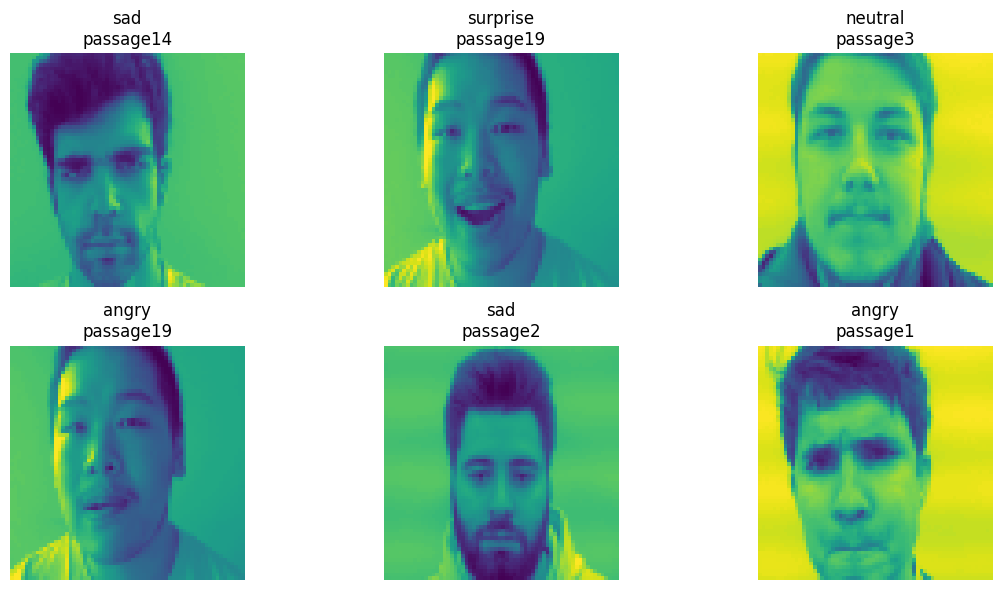

In [19]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.sample(6, random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 6))
for i in range(len(sample_df)):
    img = Image.open(sample_df.loc[i, "filepath"])
    print(img.size)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f'{sample_df.loc[i, "label"]}\n{sample_df.loc[i, "subject_id"]}')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
print("Unique labels:", df["label"].unique())
print("Number of unique labels:", df["label"].nunique())
print(df[["filepath", "label", "subject_id"]].head(20))

Unique labels: ['angry' 'happy' 'neutral' 'sad' 'surprise']
Number of unique labels: 5
                                             filepath  label subject_id
0   /content/Emotion/passage1/angry/c0_8_1_angry_0...  angry   passage1
1   /content/Emotion/passage1/angry/c0_22_0_angry_...  angry   passage1
2   /content/Emotion/passage1/angry/c0_13_9_angry_...  angry   passage1
3   /content/Emotion/passage1/angry/c0_8_4_angry_0...  angry   passage1
4   /content/Emotion/passage1/angry/c0_19_9_angry_...  angry   passage1
5   /content/Emotion/passage1/angry/c0_13_5_angry_...  angry   passage1
6   /content/Emotion/passage1/angry/c0_3_7_angry_0...  angry   passage1
7   /content/Emotion/passage1/angry/c0_8_3_angry_0...  angry   passage1
8   /content/Emotion/passage1/angry/c0_19_2_angry_...  angry   passage1
9   /content/Emotion/passage1/angry/c0_3_9_angry_0...  angry   passage1
10  /content/Emotion/passage1/angry/c0_19_3_angry_...  angry   passage1
11  /content/Emotion/passage1/angry/c0_3_2_angry_

In [21]:
df.head(5)

,filepath,label,subject_id
0,/content/Emotion/passage1/angry/c0_8_1_angry_0...,angry,passage1
1,/content/Emotion/passage1/angry/c0_22_0_angry_...,angry,passage1
2,/content/Emotion/passage1/angry/c0_13_9_angry_...,angry,passage1
3,/content/Emotion/passage1/angry/c0_8_4_angry_0...,angry,passage1
4,/content/Emotion/passage1/angry/c0_19_9_angry_...,angry,passage1


In [22]:
# from sklearn.preprocessing import LabelEncoder
# import numpy as np

# # ============================================================
# # LABEL ENCODING
# # ============================================================
# label_encoder = LabelEncoder()
# df["label_id"] = label_encoder.fit_transform(df["label"])

# class_names = list(label_encoder.classes_)
# num_classes = len(class_names)

# print("Classes:", class_names)
# print("Number of classes:", num_classes)

# print(df.head())

In [23]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ============================================================
# LABEL ENCODING FIRST
# ============================================================
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

print("\nLabel mapping:")
for i, class_name in enumerate(class_names):
    print(f"{class_name} -> {i}")

print("\nSample rows:")
print(df[["filepath", "label", "label_id", "subject_id"]].head())

Classes: ['angry', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 5

Label mapping:
angry -> 0
happy -> 1
neutral -> 2
sad -> 3
surprise -> 4

Sample rows:
                                            filepath  label  label_id  \
0  /content/Emotion/passage1/angry/c0_8_1_angry_0...  angry         0   
1  /content/Emotion/passage1/angry/c0_22_0_angry_...  angry         0   
2  /content/Emotion/passage1/angry/c0_13_9_angry_...  angry         0   
3  /content/Emotion/passage1/angry/c0_8_4_angry_0...  angry         0   
4  /content/Emotion/passage1/angry/c0_19_9_angry_...  angry         0   

  subject_id  
0   passage1  
1   passage1  
2   passage1  
3   passage1  
4   passage1  


In [24]:
# ============================================================
# SUBJECT-WISE SPLIT
# ============================================================
all_subjects = sorted(df["subject_id"].unique())

rng = np.random.default_rng(42)
shuffled_subjects = all_subjects.copy()
rng.shuffle(shuffled_subjects)

train_subjects = shuffled_subjects[:15]
val_subjects   = shuffled_subjects[15:18]
test_subjects  = shuffled_subjects[18:21]

df_train = df[df["subject_id"].isin(train_subjects)].reset_index(drop=True)
df_val   = df[df["subject_id"].isin(val_subjects)].reset_index(drop=True)
df_test  = df[df["subject_id"].isin(test_subjects)].reset_index(drop=True)

print("Train size:", len(df_train))
print("Val size  :", len(df_val))
print("Test size :", len(df_test))

print("\nTrain class distribution:")
print(df_train["label"].value_counts())

print("\nValidation class distribution:")
print(df_val["label"].value_counts())

print("\nTest class distribution:")
print(df_test["label"].value_counts())

Train size: 3750
Val size  : 750
Test size : 750

Train class distribution:
label
angry       750
happy       750
neutral     750
sad         750
surprise    750
Name: count, dtype: int64

Validation class distribution:
label
angry       150
happy       150
neutral     150
sad         150
surprise    150
Name: count, dtype: int64

Test class distribution:
label
angry       150
happy       150
neutral     150
sad         150
surprise    150
Name: count, dtype: int64


In [25]:
# ============================================================
# CHOOSE SPLIT TYPE
# ============================================================
from sklearn.model_selection import train_test_split
import numpy as np

split_type = "random"   # "random" or "subject"

if split_type == "subject":
    all_subjects = sorted(df["subject_id"].unique())

    rng = np.random.default_rng(42)
    shuffled_subjects = all_subjects.copy()
    rng.shuffle(shuffled_subjects)

    train_subjects = shuffled_subjects[:15]
    val_subjects   = shuffled_subjects[15:18]
    test_subjects  = shuffled_subjects[18:21]

    df_train = df[df["subject_id"].isin(train_subjects)].reset_index(drop=True)
    df_val   = df[df["subject_id"].isin(val_subjects)].reset_index(drop=True)
    df_test  = df[df["subject_id"].isin(test_subjects)].reset_index(drop=True)

elif split_type == "random":
    df_train, df_temp = train_test_split(
        df,
        test_size=0.30,
        stratify=df["label"],
        random_state=42,
        shuffle=True
    )

    df_val, df_test = train_test_split(
        df_temp,
        test_size=0.50,
        stratify=df_temp["label"],
        random_state=42,
        shuffle=True
    )

    df_train = df_train.reset_index(drop=True)
    df_val   = df_val.reset_index(drop=True)
    df_test  = df_test.reset_index(drop=True)

else:
    raise ValueError("split_type must be either 'random' or 'subject'")

print("Split type:", split_type)
print("Train size:", len(df_train))
print("Val size  :", len(df_val))
print("Test size :", len(df_test))

print("\nTrain class distribution:")
print(df_train["label"].value_counts())

print("\nValidation class distribution:")
print(df_val["label"].value_counts())

print("\nTest class distribution:")
print(df_test["label"].value_counts())

print("\nTrain subjects:", df_train["subject_id"].nunique())
print("Val subjects  :", df_val["subject_id"].nunique())
print("Test subjects :", df_test["subject_id"].nunique())

Split type: random
Train size: 3675
Val size  : 787
Test size : 788

Train class distribution:
label
neutral     735
surprise    735
happy       735
angry       735
sad         735
Name: count, dtype: int64

Validation class distribution:
label
happy       158
surprise    158
angry       157
sad         157
neutral     157
Name: count, dtype: int64

Test class distribution:
label
sad         158
neutral     158
angry       158
happy       157
surprise    157
Name: count, dtype: int64

Train subjects: 21
Val subjects  : 21
Test subjects : 21


The private dataset was divided using a subject-independent protocol. Fifteen passages were used for training, three for validation, and three for testing. Each split preserved a perfectly balanced distribution across the five emotion classes, with 750 training images, 150 validation images, and 150 test images per class.

#### new

In [26]:
# ============================================================
# IMAGE LOADING + TF.DATA PREPARATION
# ============================================================
from dataclasses import dataclass
from typing import Tuple
import tensorflow as tf
import matplotlib.pyplot as plt

@dataclass
class Config:
    # image settings
    image_size: Tuple[int, int] = (64, 64)
    channels: int = 1
    use_grayscale: bool = True

    # dataset settings
    batch_size: int = 32
    random_state: int = 42

    # model settings
    latent_dim: int = 64
    learning_rate: float = 1e-3
    epochs: int = 80
    l2_reg: float = 1e-4
    dropout_rate: float = 0.15

CFG = Config()
AUTOTUNE = tf.data.AUTOTUNE


def load_and_preprocess_image(path: tf.Tensor, label: tf.Tensor):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=CFG.channels, expand_animations=False)
    image = tf.image.resize(image, CFG.image_size)

    image = tf.cast(image, tf.float32) / 255.0

    if CFG.use_grayscale and CFG.channels == 1:
        image.set_shape((*CFG.image_size, 1))
    else:
        image.set_shape((*CFG.image_size, CFG.channels))

    return image, label


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
], name="data_augmentation")


def make_dataset(df_split, training=False):
    paths = df_split["filepath"].values
    labels = df_split["label_id"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df_split),
            seed=CFG.random_state,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(CFG.batch_size).prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(df_train, training=True)
val_ds   = make_dataset(df_val, training=False)
test_ds  = make_dataset(df_test, training=False)

print("train_ds:", train_ds)
print("val_ds  :", val_ds)
print("test_ds :", test_ds)
print("latent_dim:", CFG.latent_dim)
print("learning_rate:", CFG.learning_rate)

train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
val_ds  : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
test_ds : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
latent_dim: 64
learning_rate: 0.001


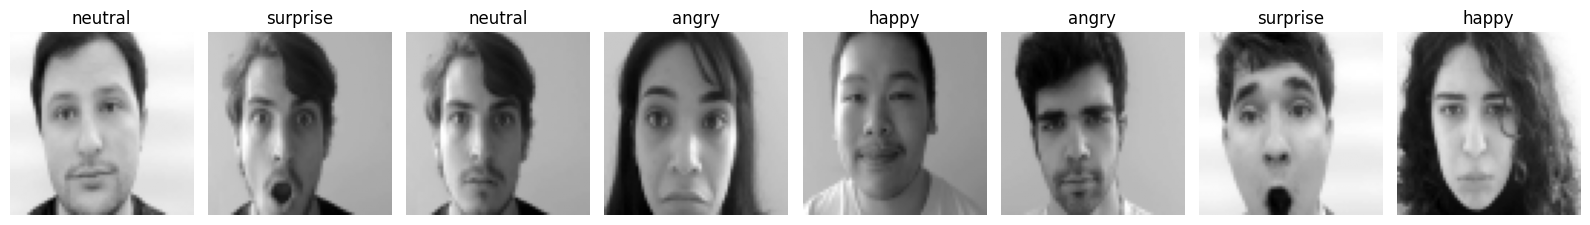

In [27]:
def show_sample_images(ds, class_names, n=8):
    for images, labels in ds.take(1):
        images = images[:n]
        labels = labels[:n]
        break

    plt.figure(figsize=(2 * n, 3))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images(train_ds, class_names, n=8)

In [28]:
len(df)

5250

# Dataset Preparation – Private Emotion Dataset

In this section, the private dataset provided by the supervisor is prepared for training the emotion recognition models.

The dataset is organized into 21 subject folders (passage1 to passage21). Each folder contains facial images extracted from video sequences located in the directory:

emotion/frame/learning

Each image filename contains the emotion label. For example:

c0_0_1_surprised_212.png

From this filename, the emotion label "surprised" is extracted automatically.

Steps performed in this section:

1. Load images from all 21 passage folders.
2. Extract emotion labels from image filenames.
3. Construct a dataframe containing:
   - filepath
   - emotion label
   - subject identifier (passage)
4. Normalize labels (e.g., "surprised" → "surprise").
5. Encode emotion labels into numerical format.
6. Perform subject-independent dataset splitting:
   - 15 passages for training
   - 3 passages for validation
   - 3 passages for testing
7. Build TensorFlow datasets using tf.data for efficient training.

Images are resized to 64×64 grayscale and normalized to the range [0,1].

The resulting datasets are:

- train_ds
- val_ds
- test_ds

These datasets will be used to train and evaluate the Autoencoder (AE) and Variational Autoencoder (VAE) models.

# Phase 2 — AE model training and evaluation

#### PHASE 2.1 - SHARED CONVOLUTION BLOCK

In [ ]:
# ============================================================
# PHASE 2.1 - SHARED CONVOLUTION BLOCK
# ============================================================
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def ae_conv_block(x, filters, l2_reg=1e-4, dropout_rate=0.15):
    x = layers.Conv2D(
        filters=filters,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

In [ ]:
# ============================================================
# PHASE 2.2 - AE ENCODER
# ============================================================
def build_private_ae_encoder(cfg):
    inputs = layers.Input(shape=(*cfg.image_size, cfg.channels), name="ae_encoder_input")

    x = data_augmentation(inputs)

    x = ae_conv_block(x, 32, l2_reg=1e-4, dropout_rate=0.10)
    x = ae_conv_block(x, 64, l2_reg=1e-4, dropout_rate=0.15)
    x = ae_conv_block(x, 128, l2_reg=1e-4, dropout_rate=0.20)

    shape_before_flatten = tf.keras.backend.int_shape(x)[1:]

    x = layers.Flatten()(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.25)(x)

    latent = layers.Dense(cfg.latent_dim, name="ae_latent")(x)

    encoder = models.Model(inputs, latent, name="Private_AE_Encoder")
    return encoder, shape_before_flatten

ae_encoder, ae_shape_before_flatten = build_private_ae_encoder(CFG)
ae_encoder.summary()

print("Shape before flatten:", ae_shape_before_flatten)

Model: "Private_AE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_encoder_input (InputLayer)   │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_188         │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_188 (LeakyReLU)     │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_189         │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_189 (LeakyReLU)     │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_190         │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_190 (LeakyReLU)     │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_191         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_191 (LeakyReLU)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_98 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_latent (Dense)               │ (None, 64)             │         8,25

 Total params: 1,151,040 (4.39 MB)

 Trainable params: 1,150,336 (4.39 MB)

 Non-trainable params: 704 (2.75 KB)

Shape before flatten: (8, 8, 128)


In [ ]:
# ============================================================
# PHASE 2.3 - AE DECODER
# ============================================================
def build_private_ae_decoder(cfg, shape_before_flatten):
    latent_inputs = layers.Input(shape=(cfg.latent_dim,), name="ae_decoder_input")

    h, w, c = shape_before_flatten

    x = layers.Dense(h * w * c)(latent_inputs)
    x = layers.Reshape((h, w, c))(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)

    x = layers.Conv2D(cfg.channels, 3, padding="same", activation="sigmoid")(x)

    # ensure exact final size
    x = layers.Resizing(cfg.image_size[0], cfg.image_size[1])(x)

    decoder = models.Model(latent_inputs, x, name="Private_AE_Decoder")
    return decoder

ae_decoder = build_private_ae_decoder(CFG, ae_shape_before_flatten)
ae_decoder.summary()

Model: "Private_AE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_decoder_input (InputLayer)   │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 8192)           │       532,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_14 (Reshape)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_50             │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_51             │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_52             │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 64, 64, 1)      │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 64, 64, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 772,609 (2.95 MB)

 Trainable params: 772,609 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# PHASE 2.4 - AE CLASSIFIER HEAD
# ============================================================
def build_private_ae_head(cfg, num_classes):
    inputs = layers.Input(shape=(cfg.latent_dim,), name="ae_head_input")

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    head = models.Model(inputs, outputs, name="Private_AE_Head")
    return head

ae_head = build_private_ae_head(CFG, num_classes)
ae_head.summary()

Model: "Private_AE_Head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_head_input (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_192         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_192 (LeakyReLU)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,741 (18.52 KB)

 Trainable params: 4,613 (18.02 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# ============================================================
# PHASE 2.5 - SUPERVISED AE MODEL
# ============================================================
class SupervisedAE(tf.keras.Model):
    def __init__(
        self,
        encoder,
        decoder,
        classifier,
        reconstruction_loss_weight=0.6,
        classification_loss_weight=1.0,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.classifier = classifier

        self.reconstruction_loss_weight = reconstruction_loss_weight
        self.classification_loss_weight = classification_loss_weight

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.cls_loss_tracker = tf.keras.metrics.Mean(name="cls_loss")
        self.acc_tracker = tf.keras.metrics.SparseCategoricalAccuracy(name="classification_accuracy")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.cls_loss_tracker,
            self.acc_tracker,
        ]

    def call(self, inputs, training=False):
        latent = self.encoder(inputs, training=training)
        reconstruction = self.decoder(latent, training=training)
        class_probs = self.classifier(latent, training=training)
        return reconstruction, class_probs

    def compute_reconstruction_loss(self, x_true, x_recon):
        per_sample = tf.reduce_mean(tf.square(x_true - x_recon), axis=[1, 2, 3])
        return tf.reduce_mean(per_sample)

    def compute_classification_loss(self, y_true, probs):
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, probs)
        return tf.reduce_mean(loss)

    def train_step(self, data):
        x, y = data

        with tf.GradientTape() as tape:
            reconstruction, probs = self(x, training=True)

            recon_loss = self.compute_reconstruction_loss(x, reconstruction)
            cls_loss = self.compute_classification_loss(y, probs)

            total_loss = (
                self.reconstruction_loss_weight * recon_loss +
                self.classification_loss_weight * cls_loss
            )

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.cls_loss_tracker.update_state(cls_loss)
        self.acc_tracker.update_state(y, probs)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data

        reconstruction, probs = self(x, training=False)

        recon_loss = self.compute_reconstruction_loss(x, reconstruction)
        cls_loss = self.compute_classification_loss(y, probs)

        total_loss = (
            self.reconstruction_loss_weight * recon_loss +
            self.classification_loss_weight * cls_loss
        )

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.cls_loss_tracker.update_state(cls_loss)
        self.acc_tracker.update_state(y, probs)

        return {m.name: m.result() for m in self.metrics}

In [ ]:
# ============================================================
# PHASE 2.6 - INSTANTIATE AND COMPILE AE
# ============================================================
private_ae = SupervisedAE(
    encoder=ae_encoder,
    decoder=ae_decoder,
    classifier=ae_head,
    reconstruction_loss_weight=0.8,# tune here 0.6,0.3,1.0
    classification_loss_weight=1.2,
    name="PrivateSupervisedAE"
)

optimizer = tf.keras.optimizers.Adam(learning_rate=CFG.learning_rate)

private_ae.compile(
    optimizer=optimizer,
    run_eagerly=True,
    jit_compile=False
)

In [ ]:
import tensorflow as tf
tf.config.optimizer.set_jit(False)
print("XLA JIT disabled.")

XLA JIT disabled.


In [ ]:
# ============================================================
# PHASE 2.7 - TRAIN AE
# ============================================================
ae_checkpoint_path = "best_private_ae.weights.h5"

callbacks_ae = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ae_checkpoint_path,
        monitor="val_classification_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_classification_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_classification_accuracy",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history_ae = private_ae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.epochs,
    callbacks=callbacks_ae,
    verbose=1
)

private_ae.load_weights(ae_checkpoint_path)
print("Best AE weights loaded.")

Epoch 1/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - classification_accuracy: 0.2099 - cls_loss: 1.9373 - loss: 2.3412 - recon_loss: 0.0205
Epoch 1: val_classification_accuracy improved from None to 0.19187, saving model to best_private_ae.weights.h5

Epoch 1: finished saving model to best_private_ae.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 355ms/step - classification_accuracy: 0.2163 - cls_loss: 1.8174 - loss: 2.1927 - recon_loss: 0.0149 - val_classification_accuracy: 0.1919 - val_cls_loss: 1.7117 - val_loss: 2.0729 - val_recon_loss: 0.0235 - learning_rate: 0.0010
Epoch 2/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - classification_accuracy: 0.2396 - cls_loss: 1.6846 - loss: 2.0286 - recon_loss: 0.0088
Epoch 2: val_classification_accuracy improved from 0.19187 to 0.21982, saving model to best_private_ae.weights.h5

Epoch 2: finished saving model to best_private_ae.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 357ms/step - classification_accuracy: 0.2465 - cls_loss: 1.6681 - loss

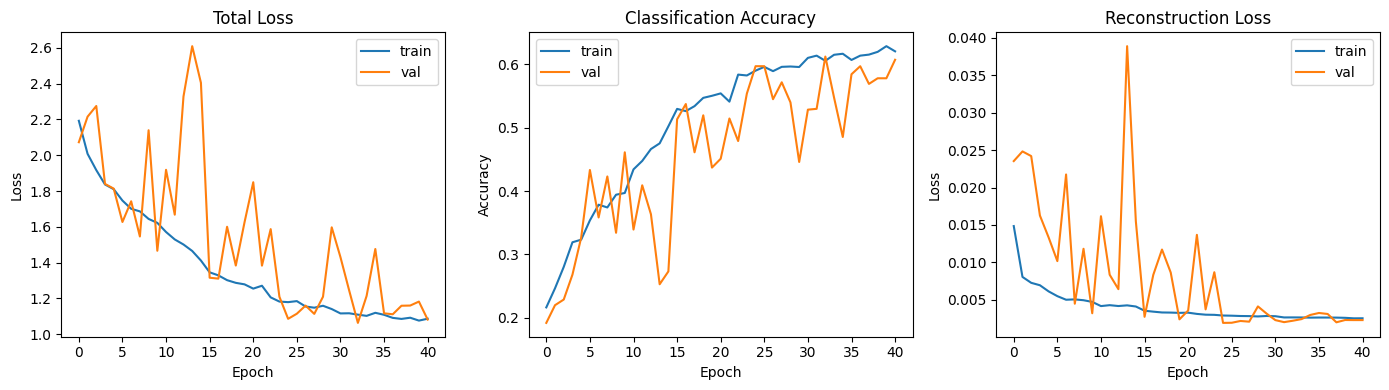

In [ ]:
# ============================================================
# PHASE 2.8 - TRAINING CURVES
# ============================================================
def plot_ae_training_history(history):
    hist = history.history

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.title("Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(hist["classification_accuracy"], label="train")
    plt.plot(hist["val_classification_accuracy"], label="val")
    plt.title("Classification Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(hist["recon_loss"], label="train")
    plt.plot(hist["val_recon_loss"], label="val")
    plt.title("Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_ae_training_history(history_ae)

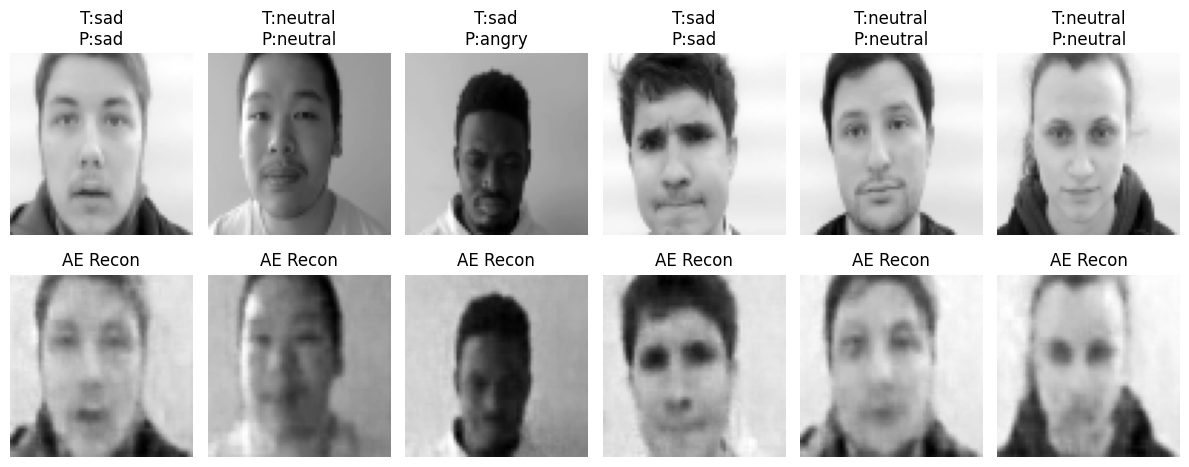

In [ ]:
# ============================================================
# PHASE 2.9 - AE RECONSTRUCTION VISUALIZATION
# ============================================================
def show_ae_reconstructions(model, ds, class_names, n=6):
    for images, labels in ds.take(1):
        images = images[:n]
        labels = labels[:n]
        break

    reconstructions, probs = model(images, training=False)
    preds = np.argmax(probs.numpy(), axis=1)

    plt.figure(figsize=(2 * n, 5))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(f"T:{class_names[int(labels[i])]}\nP:{class_names[int(preds[i])]}")
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(reconstructions[i].numpy().squeeze(), cmap="gray")
        plt.title("AE Recon")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ae_reconstructions(private_ae, test_ds, class_names, n=6)

In [ ]:
# ============================================================
# PHASE 2.10 - AE HEAD EVALUATION
# ============================================================
from sklearn.metrics import accuracy_score, classification_report

y_true_ae = []
y_pred_ae = []

for x_batch, y_batch in test_ds:
    _, probs = private_ae(x_batch, training=False)
    y_true_ae.append(y_batch.numpy())
    y_pred_ae.append(np.argmax(probs.numpy(), axis=1))

y_true_ae = np.concatenate(y_true_ae, axis=0)
y_pred_ae = np.concatenate(y_pred_ae, axis=0)

ae_head_acc = accuracy_score(y_true_ae, y_pred_ae)

print(f"AE Head Accuracy: {ae_head_acc:.4f}\n")
print(classification_report(y_true_ae, y_pred_ae, target_names=class_names, digits=4))

AE Head Accuracy: 0.6574

              precision    recall  f1-score   support

       angry     0.5000    0.8354    0.6256       158
       happy     0.7528    0.8535    0.8000       157
     neutral     0.7606    0.3418    0.4716       158
         sad     0.4845    0.2975    0.3686       158
    surprise     0.8483    0.9618    0.9015       157

    accuracy                         0.6574       788
   macro avg     0.6692    0.6580    0.6335       788
weighted avg     0.6689    0.6574    0.6329       788



In [ ]:
# ============================================================
# PHASE 2.1 - SHARED CONVOLUTION BLOCK
# ============================================================
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def ae_conv_block(x, filters, l2_reg=1e-4, dropout_rate=0.15):
    x = layers.Conv2D(
        filters=filters,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

In [ ]:
# ============================================================
# PHASE 2.2 - AE ENCODER
# ============================================================
def build_private_ae_encoder(cfg):
    inputs = layers.Input(shape=(*cfg.image_size, cfg.channels), name="ae_encoder_input")

    x = data_augmentation(inputs)

    x = ae_conv_block(x, 32, l2_reg=1e-4, dropout_rate=0.10)
    x = ae_conv_block(x, 64, l2_reg=1e-4, dropout_rate=0.15)
    x = ae_conv_block(x, 128, l2_reg=1e-4, dropout_rate=0.20)

    shape_before_flatten = tf.keras.backend.int_shape(x)[1:]

    x = layers.Flatten()(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.25)(x)

    latent = layers.Dense(cfg.latent_dim, name="ae_latent")(x)

    encoder = models.Model(inputs, latent, name="Private_AE_Encoder")
    return encoder, shape_before_flatten

ae_encoder, ae_shape_before_flatten = build_private_ae_encoder(CFG)
ae_encoder.summary()

print("Shape before flatten:", ae_shape_before_flatten)

Model: "Private_AE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_encoder_input (InputLayer)   │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_188         │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_188 (LeakyReLU)     │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_189         │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_189 (LeakyReLU)     │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_190         │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_190 (LeakyReLU)     │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_191         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_191 (LeakyReLU)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_98 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_latent (Dense)               │ (None, 64)             │         8,25

 Total params: 1,151,040 (4.39 MB)

 Trainable params: 1,150,336 (4.39 MB)

 Non-trainable params: 704 (2.75 KB)

Shape before flatten: (8, 8, 128)


In [ ]:
# ============================================================
# PHASE 2.3 - AE DECODER
# ============================================================
def build_private_ae_decoder(cfg, shape_before_flatten):
    latent_inputs = layers.Input(shape=(cfg.latent_dim,), name="ae_decoder_input")

    h, w, c = shape_before_flatten

    x = layers.Dense(h * w * c)(latent_inputs)
    x = layers.Reshape((h, w, c))(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)

    x = layers.Conv2D(cfg.channels, 3, padding="same", activation="sigmoid")(x)

    # ensure exact final size
    x = layers.Resizing(cfg.image_size[0], cfg.image_size[1])(x)

    decoder = models.Model(latent_inputs, x, name="Private_AE_Decoder")
    return decoder

ae_decoder = build_private_ae_decoder(CFG, ae_shape_before_flatten)
ae_decoder.summary()

Model: "Private_AE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_decoder_input (InputLayer)   │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 8192)           │       532,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_14 (Reshape)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_50             │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_51             │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_52             │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 64, 64, 1)      │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 64, 64, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 772,609 (2.95 MB)

 Trainable params: 772,609 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# PHASE 2.4 - AE CLASSIFIER HEAD
# ============================================================
def build_private_ae_head(cfg, num_classes):
    inputs = layers.Input(shape=(cfg.latent_dim,), name="ae_head_input")

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    head = models.Model(inputs, outputs, name="Private_AE_Head")
    return head

ae_head = build_private_ae_head(CFG, num_classes)
ae_head.summary()

Model: "Private_AE_Head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_head_input (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_192         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_192 (LeakyReLU)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,741 (18.52 KB)

 Trainable params: 4,613 (18.02 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# ============================================================
# PHASE 2.5 - SUPERVISED AE MODEL
# ============================================================
class SupervisedAE(tf.keras.Model):
    def __init__(
        self,
        encoder,
        decoder,
        classifier,
        reconstruction_loss_weight=0.6,
        classification_loss_weight=1.0,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.classifier = classifier

        self.reconstruction_loss_weight = reconstruction_loss_weight
        self.classification_loss_weight = classification_loss_weight

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.cls_loss_tracker = tf.keras.metrics.Mean(name="cls_loss")
        self.acc_tracker = tf.keras.metrics.SparseCategoricalAccuracy(name="classification_accuracy")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.cls_loss_tracker,
            self.acc_tracker,
        ]

    def call(self, inputs, training=False):
        latent = self.encoder(inputs, training=training)
        reconstruction = self.decoder(latent, training=training)
        class_probs = self.classifier(latent, training=training)
        return reconstruction, class_probs

    def compute_reconstruction_loss(self, x_true, x_recon):
        per_sample = tf.reduce_mean(tf.square(x_true - x_recon), axis=[1, 2, 3])
        return tf.reduce_mean(per_sample)

    def compute_classification_loss(self, y_true, probs):
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, probs)
        return tf.reduce_mean(loss)

    def train_step(self, data):
        x, y = data

        with tf.GradientTape() as tape:
            reconstruction, probs = self(x, training=True)

            recon_loss = self.compute_reconstruction_loss(x, reconstruction)
            cls_loss = self.compute_classification_loss(y, probs)

            total_loss = (
                self.reconstruction_loss_weight * recon_loss +
                self.classification_loss_weight * cls_loss
            )

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.cls_loss_tracker.update_state(cls_loss)
        self.acc_tracker.update_state(y, probs)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data

        reconstruction, probs = self(x, training=False)

        recon_loss = self.compute_reconstruction_loss(x, reconstruction)
        cls_loss = self.compute_classification_loss(y, probs)

        total_loss = (
            self.reconstruction_loss_weight * recon_loss +
            self.classification_loss_weight * cls_loss
        )

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.cls_loss_tracker.update_state(cls_loss)
        self.acc_tracker.update_state(y, probs)

        return {m.name: m.result() for m in self.metrics}

In [ ]:
# ============================================================
# PHASE 2.6 - INSTANTIATE AND COMPILE AE
# ============================================================
private_ae = SupervisedAE(
    encoder=ae_encoder,
    decoder=ae_decoder,
    classifier=ae_head,
    reconstruction_loss_weight=0.8,# tune here 0.6,0.3,1.0
    classification_loss_weight=1.2,
    name="PrivateSupervisedAE"
)

optimizer = tf.keras.optimizers.Adam(learning_rate=CFG.learning_rate)

private_ae.compile(
    optimizer=optimizer,
    run_eagerly=True,
    jit_compile=False
)

In [ ]:
import tensorflow as tf
tf.config.optimizer.set_jit(False)
print("XLA JIT disabled.")

XLA JIT disabled.


In [ ]:
# ============================================================
# PHASE 2.7 - TRAIN AE
# ============================================================
ae_checkpoint_path = "best_private_ae.weights.h5"

callbacks_ae = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ae_checkpoint_path,
        monitor="val_classification_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_classification_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_classification_accuracy",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history_ae = private_ae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.epochs,
    callbacks=callbacks_ae,
    verbose=1
)

private_ae.load_weights(ae_checkpoint_path)
print("Best AE weights loaded.")

Epoch 1/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - classification_accuracy: 0.2099 - cls_loss: 1.9373 - loss: 2.3412 - recon_loss: 0.0205
Epoch 1: val_classification_accuracy improved from None to 0.19187, saving model to best_private_ae.weights.h5

Epoch 1: finished saving model to best_private_ae.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 355ms/step - classification_accuracy: 0.2163 - cls_loss: 1.8174 - loss: 2.1927 - recon_loss: 0.0149 - val_classification_accuracy: 0.1919 - val_cls_loss: 1.7117 - val_loss: 2.0729 - val_recon_loss: 0.0235 - learning_rate: 0.0010
Epoch 2/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - classification_accuracy: 0.2396 - cls_loss: 1.6846 - loss: 2.0286 - recon_loss: 0.0088
Epoch 2: val_classification_accuracy improved from 0.19187 to 0.21982, saving model to best_private_ae.weights.h5

Epoch 2: finished saving model to best_private_ae.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 357ms/step - classification_accuracy: 0.2465 - cls_loss: 1.6681 - loss

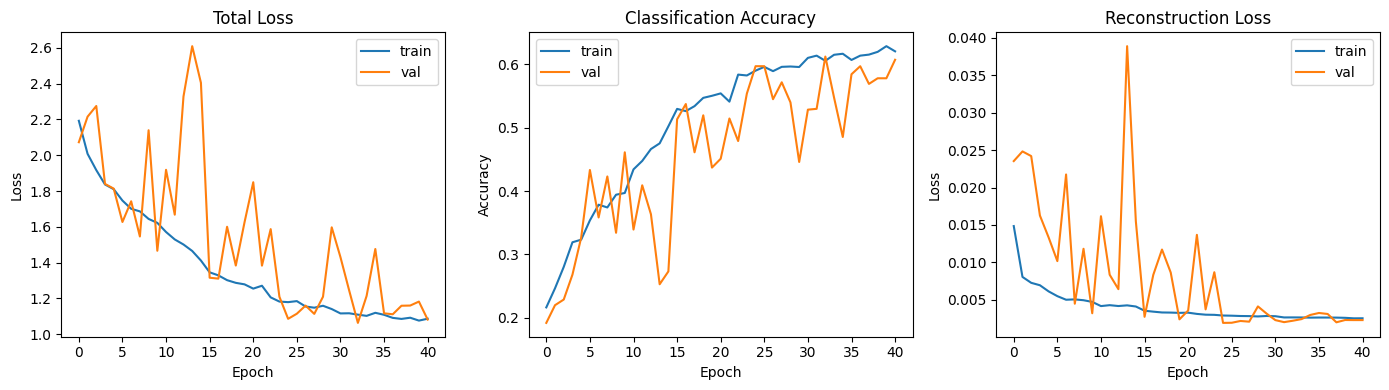

In [ ]:
# ============================================================
# PHASE 2.8 - TRAINING CURVES
# ============================================================
def plot_ae_training_history(history):
    hist = history.history

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.title("Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(hist["classification_accuracy"], label="train")
    plt.plot(hist["val_classification_accuracy"], label="val")
    plt.title("Classification Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(hist["recon_loss"], label="train")
    plt.plot(hist["val_recon_loss"], label="val")
    plt.title("Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_ae_training_history(history_ae)

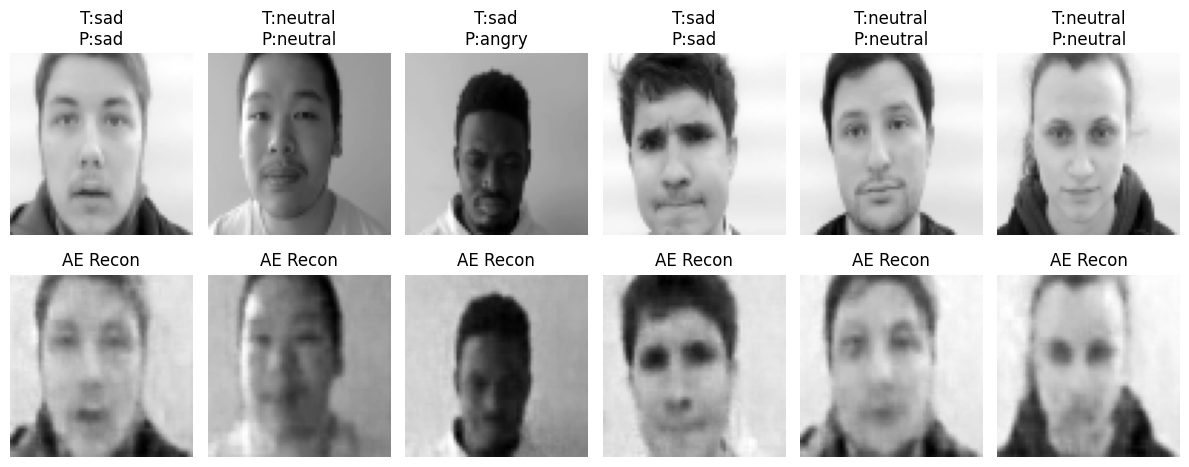

In [ ]:
# ============================================================
# PHASE 2.9 - AE RECONSTRUCTION VISUALIZATION
# ============================================================
def show_ae_reconstructions(model, ds, class_names, n=6):
    for images, labels in ds.take(1):
        images = images[:n]
        labels = labels[:n]
        break

    reconstructions, probs = model(images, training=False)
    preds = np.argmax(probs.numpy(), axis=1)

    plt.figure(figsize=(2 * n, 5))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(f"T:{class_names[int(labels[i])]}\nP:{class_names[int(preds[i])]}")
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(reconstructions[i].numpy().squeeze(), cmap="gray")
        plt.title("AE Recon")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ae_reconstructions(private_ae, test_ds, class_names, n=6)

In [ ]:
# ============================================================
# PHASE 2.10 - AE HEAD EVALUATION
# ============================================================
from sklearn.metrics import accuracy_score, classification_report

y_true_ae = []
y_pred_ae = []

for x_batch, y_batch in test_ds:
    _, probs = private_ae(x_batch, training=False)
    y_true_ae.append(y_batch.numpy())
    y_pred_ae.append(np.argmax(probs.numpy(), axis=1))

y_true_ae = np.concatenate(y_true_ae, axis=0)
y_pred_ae = np.concatenate(y_pred_ae, axis=0)

ae_head_acc = accuracy_score(y_true_ae, y_pred_ae)

print(f"AE Head Accuracy: {ae_head_acc:.4f}\n")
print(classification_report(y_true_ae, y_pred_ae, target_names=class_names, digits=4))

AE Head Accuracy: 0.6574

              precision    recall  f1-score   support

       angry     0.5000    0.8354    0.6256       158
       happy     0.7528    0.8535    0.8000       157
     neutral     0.7606    0.3418    0.4716       158
         sad     0.4845    0.2975    0.3686       158
    surprise     0.8483    0.9618    0.9015       157

    accuracy                         0.6574       788
   macro avg     0.6692    0.6580    0.6335       788
weighted avg     0.6689    0.6574    0.6329       788



In [ ]:
# ============================================================
# PHASE 2.11 - EXTRACT AE LATENT FEATURES
# ============================================================
def extract_ae_latent_features(ds_batched, encoder_model):
    X_latent = []
    y_all = []

    for x_batch, y_batch in ds_batched:
        z = encoder_model(x_batch, training=False)
        X_latent.append(z.numpy())
        y_all.append(y_batch.numpy())

    X_latent = np.concatenate(X_latent, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    return X_latent, y_all

X_train_ae, y_train_ae_latent = extract_ae_latent_features(train_ds, ae_encoder)
X_val_ae, y_val_ae_latent     = extract_ae_latent_features(val_ds, ae_encoder)
X_test_ae, y_test_ae_latent   = extract_ae_latent_features(test_ds, ae_encoder)

print("Train latent shape:", X_train_ae.shape)
print("Validation latent shape:", X_val_ae.shape)
print("Test latent shape:", X_test_ae.shape)

Train latent shape: (3675, 64)
Validation latent shape: (787, 64)
Test latent shape: (788, 64)


In [ ]:
# ============================================================
# PHASE 2.12 - STANDARDIZE AE LATENT FEATURES
# ============================================================
from sklearn.preprocessing import StandardScaler

ae_scaler = StandardScaler()
X_train_ae_scaled = ae_scaler.fit_transform(X_train_ae)
X_val_ae_scaled   = ae_scaler.transform(X_val_ae)
X_test_ae_scaled  = ae_scaler.transform(X_test_ae)

print(X_train_ae_scaled.shape, X_test_ae_scaled.shape)

(3675, 64) (788, 64)


In [ ]:
# # ============================================================
# # PHASE 2.13 - AE LATENT + MLP
# # ============================================================
# from sklearn.neural_network import MLPClassifier

# ae_mlp_classifier = MLPClassifier(
#     hidden_layer_sizes=(128, 64),
#     activation="relu",
#     alpha=1e-4,
#     learning_rate_init=1e-3,
#     max_iter=500,
#     early_stopping=True,
#     validation_fraction=0.1,
#     n_iter_no_change=15,
#     random_state=42
# )

# ae_mlp_classifier.fit(X_train_ae_scaled, y_train_ae_latent)

# y_pred_ae_mlp = ae_mlp_classifier.predict(X_test_ae_scaled)
# ae_mlp_acc = accuracy_score(y_test_ae_latent, y_pred_ae_mlp)

# print(f"AE Latent + MLP Accuracy: {ae_mlp_acc:.4f}\n")
# print(classification_report(y_test_ae_latent, y_pred_ae_mlp, target_names=class_names, digits=4))

In [ ]:
# ============================================================
# 24) BUILD MLP CLASSIFIER
# ============================================================
def build_mlp_classifier(input_dim, num_classes):
    inputs = tf.keras.Input(shape=(input_dim,), name="mlp_input")

    x = tf.keras.layers.Dense(256)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    x = tf.keras.layers.Dense(128)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)
    x = tf.keras.layers.Dropout(0.20)(x)

    x = tf.keras.layers.Dense(64)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)
    x = tf.keras.layers.Dropout(0.15)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs, name="MLP_Latent_Classifier")

mlp_classifier = build_mlp_classifier(CFG.latent_dim, num_classes)
mlp_classifier.summary()

Model: "MLP_Latent_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mlp_input (InputLayer)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_193         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_193 (LeakyReLU)     │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_194         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_194 (LeakyReLU)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_195         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_195 (LeakyReLU)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_102 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,909 (234.02 KB)

 Trainable params: 59,013 (230.52 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# ============================================================
# 25) TRAIN MLP CLASSIFIER
# ============================================================
mlp_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_mlp = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_mlp_classifier.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]


history_mlp = mlp_classifier.fit(
    X_train_ae_scaled, y_train_ae_latent,
    validation_data=(X_val_ae_scaled, y_val_ae_latent),
    epochs=CFG.epochs,
    batch_size=256,
    callbacks=callbacks_mlp,
    verbose=1,
)

Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.4065 - loss: 1.5213
Epoch 1: val_accuracy improved from None to 0.64803, saving model to best_mlp_classifier.keras

Epoch 1: finished saving model to best_mlp_classifier.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 303ms/step - accuracy: 0.5254 - loss: 1.1967 - val_accuracy: 0.6480 - val_loss: 0.8646 - learning_rate: 0.0010
Epoch 2/80
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6875 - loss: 0.7750
Epoch 2: val_accuracy improved from 0.64803 to 0.69123, saving model to best_mlp_classifier.keras

Epoch 2: finished saving model to best_mlp_classifier.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6827 - loss: 0.7839 - val_accuracy: 0.6912 - val_loss: 0.7708 - learning_rate: 0.0010
Epoch 3/80
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7227 - loss: 0.6417
Epoch 3: val_accuracy improved from 0.69123 to 0.71283, saving model to best_mlp_classifier.keras

Epoch 3: finished saving model to best_mlp_classi

In [ ]:
# ============================================================
# 26) EVALUATE MLP
# ============================================================
mlp_classifier = tf.keras.models.load_model("best_mlp_classifier.keras")

y_pred_mlp_prob = mlp_classifier.predict(X_test_ae_scaled, verbose=0)
y_pred_mlp = np.argmax(y_pred_mlp_prob, axis=1)

mlp_acc = accuracy_score(y_test_ae_latent, y_pred_mlp)
print(f"MLP Test Accuracy: {mlp_acc:.4f}\n")

print("MLP Classification Report:")
print(classification_report(y_test_ae_latent, y_pred_mlp, target_names=class_names, digits=4))

MLP Test Accuracy: 0.8731

MLP Classification Report:
              precision    recall  f1-score   support

       angry     0.8047    0.8608    0.8318       158
       happy     0.9662    0.9108    0.9377       157
     neutral     0.8333    0.9177    0.8735       158
         sad     0.8273    0.7278    0.7744       158
    surprise     0.9430    0.9490    0.9460       157

    accuracy                         0.8731       788
   macro avg     0.8749    0.8732    0.8727       788
weighted avg     0.8747    0.8731    0.8725       788



In [ ]:
# ============================================================
# PHASE 2.14 AE LATENT + LMS CLASSIFIER
# ============================================================
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

ae_lms_classifier = SGDClassifier(
    loss="squared_error",   # LMS objective
    learning_rate="optimal",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

ae_lms_classifier.fit(X_train_ae_scaled, y_train_ae_latent)

y_pred_ae_lms = ae_lms_classifier.predict(X_test_ae_scaled)

ae_lms_acc = accuracy_score(y_test_ae_latent, y_pred_ae_lms)

print(f"AE Latent + LMS Accuracy: {ae_lms_acc:.4f}\n")

print(classification_report(
    y_test_ae_latent,
    y_pred_ae_lms,
    target_names=class_names,
    digits=4
))

AE Latent + LMS Accuracy: 0.1929

              precision    recall  f1-score   support

       angry     0.1667    0.2278    0.1925       158
       happy     0.0323    0.0064    0.0106       157
     neutral     0.1863    0.3797    0.2500       158
         sad     0.3023    0.0823    0.1294       158
    surprise     0.2386    0.2675    0.2523       157

    accuracy                         0.1929       788
   macro avg     0.1852    0.1928    0.1670       788
weighted avg     0.1854    0.1929    0.1670       788



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


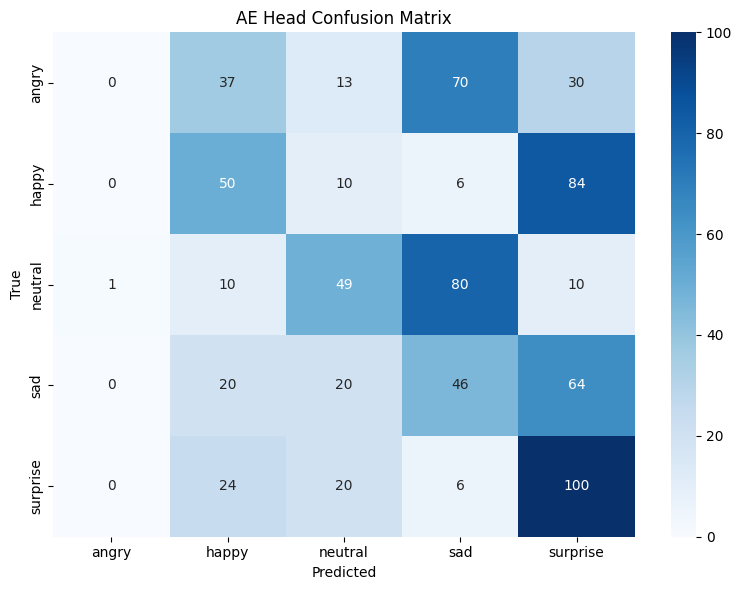

In [ ]:
# ============================================================
# PHASE 2.15 - AE CONFUSION MATRIX
# ============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_conf_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_true_ae, y_pred_ae, class_names, "AE Head Confusion Matrix")

In [ ]:
# ============================================================
# PHASE 2.16 - AE RECONSTRUCTION METRICS
# ============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error

def get_ae_reconstruction(model, x_batch):
    reconstruction, probs = model(x_batch, training=False)
    return reconstruction

def evaluate_ae_reconstruction_metrics(ds, model):
    mse_list = []
    mae_list = []

    for x_batch, _ in ds:
        recon_batch = get_ae_reconstruction(model, x_batch)

        x_true = x_batch.numpy()
        x_rec = recon_batch.numpy()

        for i in range(len(x_true)):
            mse_list.append(mean_squared_error(x_true[i].ravel(), x_rec[i].ravel()))
            mae_list.append(mean_absolute_error(x_true[i].ravel(), x_rec[i].ravel()))

    return {
        "MSE": float(np.mean(mse_list)),
        "MAE": float(np.mean(mae_list)),
    }

ae_recon_metrics = evaluate_ae_reconstruction_metrics(test_ds, private_ae)
print("AE Reconstruction Metrics:", ae_recon_metrics)

AE Reconstruction Metrics: {'MSE': 0.02253163597981135, 'MAE': 0.10181584131717682}


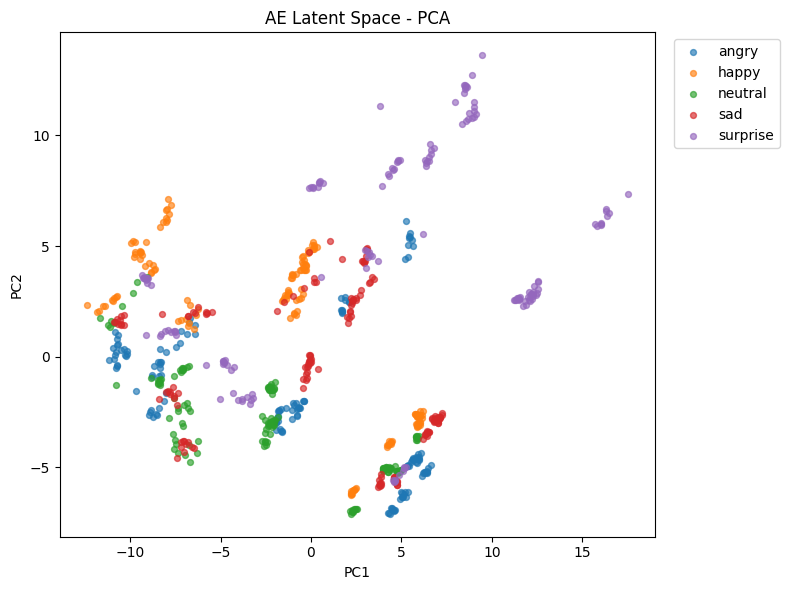

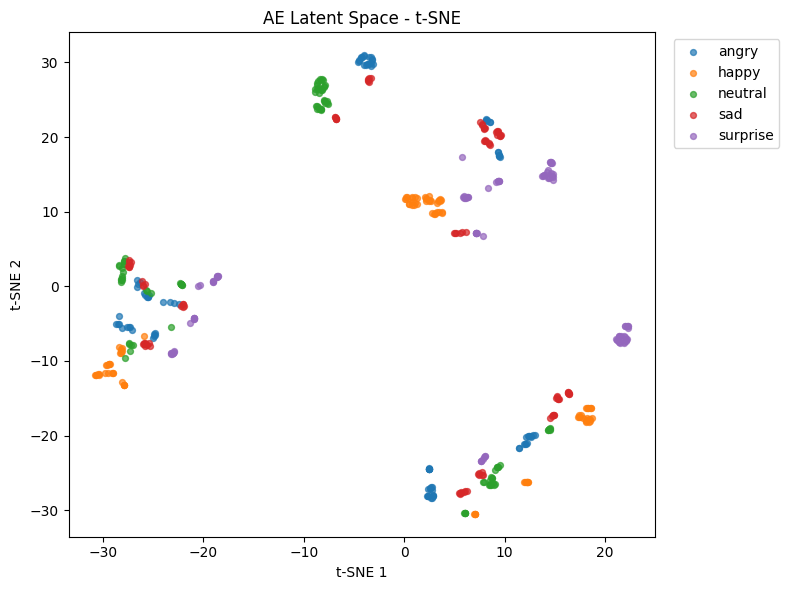

In [ ]:
# ============================================================
# PHASE 2.17 - AE LATENT SPACE VISUALIZATION
# ============================================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_pca_latent(X, y, class_names, title):
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        mask = (y == i)
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=18, alpha=0.65, label=class_name)

    plt.title(f"{title} - PCA")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_tsne_latent(X, y, class_names, title, sample_size=500):
    rng = np.random.default_rng(42)

    if len(X) > sample_size:
        idx = rng.choice(len(X), sample_size, replace=False)
        X = X[idx]
        y = y[idx]

    X_pca = PCA(n_components=min(20, X.shape[1], len(X) - 1), random_state=42).fit_transform(X)

    X_2d = TSNE(
        n_components=2,
        perplexity=min(30, max(5, len(X) // 10)),
        learning_rate="auto",
        init="pca",
        random_state=42
    ).fit_transform(X_pca)

    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        mask = (y == i)
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=18, alpha=0.70, label=class_name)

    plt.title(f"{title} - t-SNE")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_pca_latent(X_test_ae, y_test_ae_latent, class_names, "AE Latent Space")
plot_tsne_latent(X_test_ae, y_test_ae_latent, class_names, "AE Latent Space")

In [ ]:
# ============================================================
# PHASE 2.18 - AE FINAL SUMMARY
# ============================================================
print("=" * 60)
print("PHASE 2 - PRIVATE DATASET AE SUMMARY")
print("=" * 60)
print(f"AE Head Accuracy        : {ae_head_acc:.4f}")
print(f"AE Latent + MLP         : {ae_mlp_acc:.4f}")
print(f"AE Latent + LMS         : {ae_lms_acc:.4f}")
print(f"AE Reconstruction MSE   : {ae_recon_metrics['MSE']:.6f}")
print(f"AE Reconstruction MAE   : {ae_recon_metrics['MAE']:.6f}")

PHASE 2 - PRIVATE DATASET AE SUMMARY
AE Head Accuracy        : 0.3267
AE Latent + MLP         : 0.3240
AE Latent + LMS         : 0.2147
AE Reconstruction MSE   : 0.022532
AE Reconstruction MAE   : 0.101816


Total test images: 750


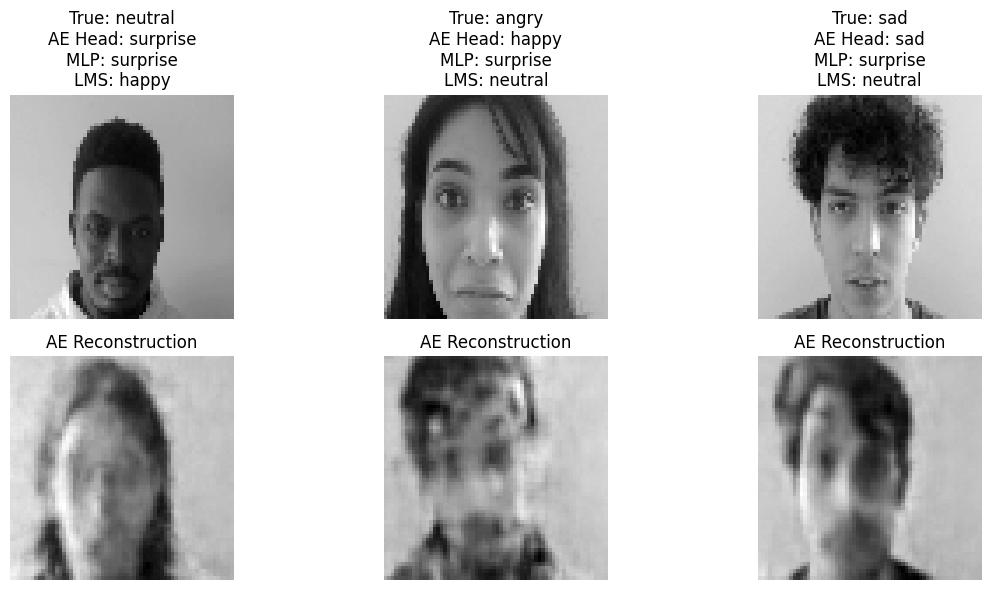

IMAGE 1
True Label: neutral
AE Head Prediction: surprise
MLP Prediction: surprise
LMS Prediction: happy

AE Head Probabilities:
angry     : 0.0222
happy     : 0.0091
neutral   : 0.0644
sad       : 0.2461
surprise  : 0.6582

IMAGE 2
True Label: angry
AE Head Prediction: happy
MLP Prediction: surprise
LMS Prediction: neutral

AE Head Probabilities:
angry     : 0.1326
happy     : 0.6294
neutral   : 0.1445
sad       : 0.0787
surprise  : 0.0148

IMAGE 3
True Label: sad
AE Head Prediction: sad
MLP Prediction: surprise
LMS Prediction: neutral

AE Head Probabilities:
angry     : 0.2398
happy     : 0.1181
neutral   : 0.2391
sad       : 0.2566
surprise  : 0.1464



In [ ]:
# ============================================================
# RANDOM IMAGE PREDICTION (AE HEAD + MLP + LMS)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# collect all test images and labels
all_test_images = []
all_test_labels = []

for img_batch, lab_batch in test_ds:
    all_test_images.append(img_batch.numpy())
    all_test_labels.append(lab_batch.numpy())

all_test_images = np.concatenate(all_test_images, axis=0)
all_test_labels = np.concatenate(all_test_labels, axis=0)

print("Total test images:", len(all_test_images))


# select random images
np.random.seed(42)
indices = np.random.choice(len(all_test_images), size=3, replace=False)

selected_images = all_test_images[indices]
selected_labels = all_test_labels[indices]


# ============================================================
# AE HEAD PREDICTION
# ============================================================
reconstructions, ae_head_probs = private_ae(selected_images, training=False)
ae_head_probs = ae_head_probs.numpy()
ae_head_preds = np.argmax(ae_head_probs, axis=1)


# ============================================================
# LATENT FEATURES
# ============================================================
latent = ae_encoder(selected_images, training=False).numpy()

latent_scaled = ae_scaler.transform(latent)


# ============================================================
# MLP PREDICTION
# ============================================================
mlp_probs = ae_mlp_classifier.predict_proba(latent_scaled)
mlp_preds = np.argmax(mlp_probs, axis=1)


# ============================================================
# LINEAR CLASSIFIER PREDICTION
# ============================================================
linear_preds = ae_lms_classifier.predict(latent_scaled)


# ============================================================
# VISUALIZATION
# ============================================================
plt.figure(figsize=(12,6))

for i in range(3):

    # original image
    plt.subplot(2,3,i+1)
    plt.imshow(selected_images[i].squeeze(), cmap="gray")

    plt.title(
        f"True: {class_names[int(selected_labels[i])]}\n"
        f"AE Head: {class_names[int(ae_head_preds[i])]}\n"
        f"MLP: {class_names[int(mlp_preds[i])]}\n"
        f"LMS: {class_names[int(linear_preds[i])]}"
    )

    plt.axis("off")

    # reconstruction
    plt.subplot(2,3,i+4)
    plt.imshow(reconstructions[i].numpy().squeeze(), cmap="gray")
    plt.title("AE Reconstruction")
    plt.axis("off")


plt.tight_layout()
plt.show()


# ============================================================
# PRINT PROBABILITIES
# ============================================================
for i in range(3):

    print("="*60)
    print(f"IMAGE {i+1}")
    print("True Label:", class_names[int(selected_labels[i])])

    print("AE Head Prediction:", class_names[int(ae_head_preds[i])])
    print("MLP Prediction:", class_names[int(mlp_preds[i])])
    print("LMS Prediction:", class_names[int(linear_preds[i])])

    print("\nAE Head Probabilities:")
    for j, emotion in enumerate(class_names):
        print(f"{emotion:10s}: {ae_head_probs[i][j]:.4f}")

    print()

Total test images: 750


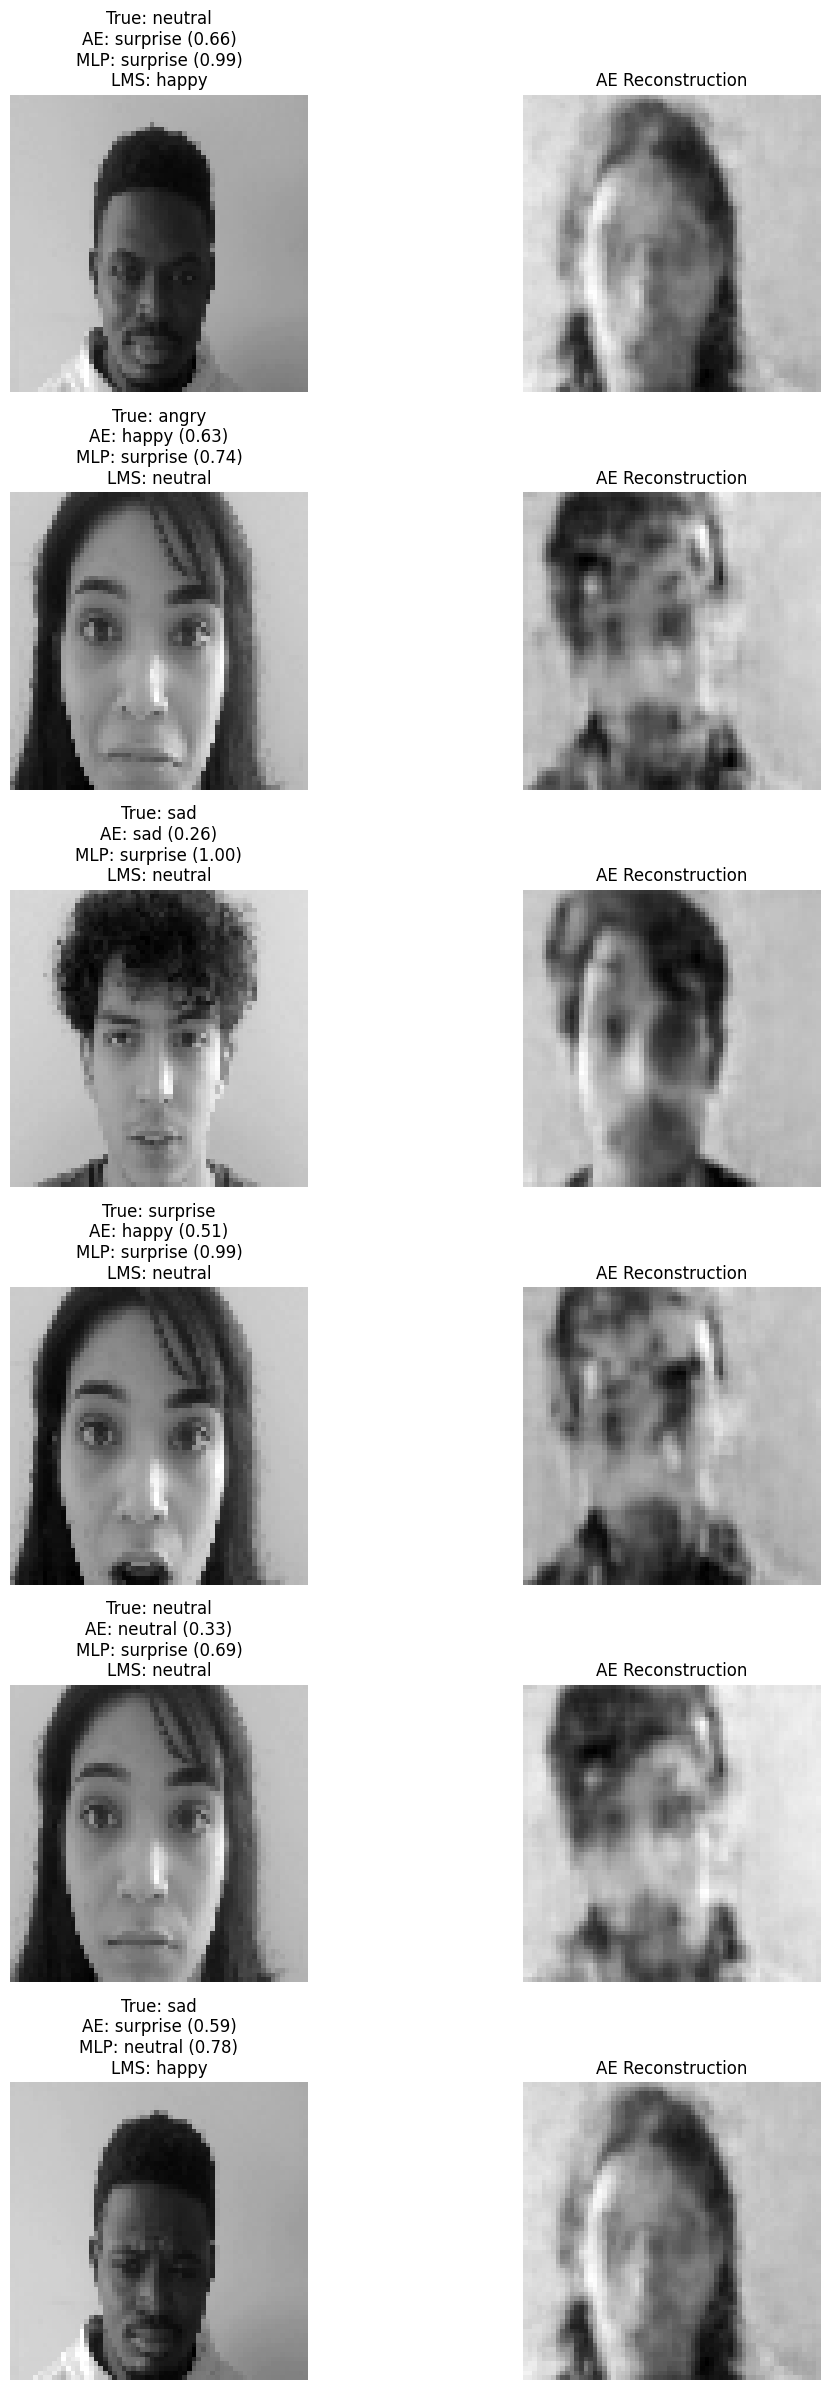

In [ ]:
# ============================================================
# RANDOM IMAGE PREDICTION (AE HEAD + MLP + LMS)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Collect all test images
# ------------------------------------------------------------
all_test_images = []
all_test_labels = []

for img_batch, lab_batch in test_ds:
    all_test_images.append(img_batch.numpy())
    all_test_labels.append(lab_batch.numpy())

all_test_images = np.concatenate(all_test_images, axis=0)
all_test_labels = np.concatenate(all_test_labels, axis=0)

print("Total test images:", len(all_test_images))

# ------------------------------------------------------------
# Select RANDOM images
# ------------------------------------------------------------
num_samples = 6
np.random.seed(42)

indices = np.random.choice(len(all_test_images), size=num_samples, replace=False)

selected_images = all_test_images[indices]
selected_labels = all_test_labels[indices]

# ------------------------------------------------------------
# AE HEAD prediction
# ------------------------------------------------------------
reconstructions, ae_probs = private_ae(selected_images, training=False)

ae_probs = ae_probs.numpy()
ae_preds = np.argmax(ae_probs, axis=1)

# ------------------------------------------------------------
# LATENT FEATURES
# ------------------------------------------------------------
latent = ae_encoder(selected_images, training=False).numpy()
latent_scaled = ae_scaler.transform(latent)

# ------------------------------------------------------------
# MLP prediction
# ------------------------------------------------------------
mlp_probs = ae_mlp_classifier.predict_proba(latent_scaled)
mlp_preds = np.argmax(mlp_probs, axis=1)

# ------------------------------------------------------------
# LMS prediction
# ------------------------------------------------------------
lms_preds = ae_lms_classifier.predict(latent_scaled)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
plt.figure(figsize=(12, 4 * num_samples))

for i in range(num_samples):

    # Original image
    plt.subplot(num_samples, 2, 2*i + 1)
    plt.imshow(selected_images[i].squeeze(), cmap="gray")

    ae_conf = np.max(ae_probs[i])
    mlp_conf = np.max(mlp_probs[i])

    plt.title(
        f"True: {class_names[int(selected_labels[i])]}\n"
        f"AE: {class_names[int(ae_preds[i])]} ({ae_conf:.2f})\n"
        f"MLP: {class_names[int(mlp_preds[i])]} ({mlp_conf:.2f})\n"
        f"LMS: {class_names[int(lms_preds[i])]}"
    )

    plt.axis("off")

    # Reconstruction
    plt.subplot(num_samples, 2, 2*i + 2)
    plt.imshow(reconstructions[i].numpy().squeeze(), cmap="gray")
    plt.title("AE Reconstruction")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Phase 3 — VAE model training and evaluation

In [19]:
# ============================================================
# PHASE 3.1 - VAE SAMPLING LAYER
# ============================================================
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

class Sampling(layers.Layer):
    def call(self, inputs, training=None):
        z_mean, z_log_var = inputs

        if training:
            epsilon = tf.random.normal(shape=tf.shape(z_mean))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon
        else:
            # deterministic latent during inference
            return z_mean

In [20]:
# ============================================================
# PHASE 3.2 - SHARED CONVOLUTION BLOCK
# ============================================================
def vae_conv_block(x, filters, l2_reg=1e-4, dropout_rate=0.15):
    x = layers.Conv2D(
        filters=filters,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

In [21]:
# ============================================================
# PHASE 3.3 - VAE ENCODER
# ============================================================
def build_private_vae_encoder(cfg):
    inputs = layers.Input(shape=(*cfg.image_size, cfg.channels), name="vae_encoder_input")

    x = data_augmentation(inputs)

    x = vae_conv_block(x, 32, l2_reg=cfg.l2_reg, dropout_rate=0.10)
    x = vae_conv_block(x, 64, l2_reg=cfg.l2_reg, dropout_rate=0.15)
    x = vae_conv_block(x, 128, l2_reg=cfg.l2_reg, dropout_rate=0.20)

    shape_before_flatten = tf.keras.backend.int_shape(x)[1:]

    x = layers.Flatten()(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(cfg.l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(cfg.dropout_rate)(x)

    z_mean = layers.Dense(cfg.latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(cfg.latent_dim, name="z_log_var")(x)
    z = Sampling(name="z")([z_mean, z_log_var])

    encoder = models.Model(inputs, [z_mean, z_log_var, z], name="Private_VAE_Encoder")
    return encoder, shape_before_flatten

vae_encoder, vae_shape_before_flatten = build_private_vae_encoder(CFG)
vae_encoder.summary()

print("Shape before flatten:", vae_shape_before_flatten)

Model: "Private_VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 64, 64, 1) │          0 │ vae_encoder_inpu… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        320 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ leaky_re_lu[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ leaky_re_lu_1[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ leaky_re_lu_2[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8, 8, 128) │          0 │ max_pooling2d_2[

 Total params: 1,159,296 (4.42 MB)

 Trainable params: 1,158,592 (4.42 MB)

 Non-trainable params: 704 (2.75 KB)

Shape before flatten: (8, 8, 128)


In [22]:
# ============================================================
# PHASE 3.4 - VAE DECODER
# ============================================================
def build_private_vae_decoder(cfg, shape_before_flatten):
    latent_inputs = layers.Input(shape=(cfg.latent_dim,), name="vae_decoder_input")

    h, w, c = shape_before_flatten

    x = layers.Dense(h * w * c)(latent_inputs)
    x = layers.Reshape((h, w, c))(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)

    x = layers.Conv2D(cfg.channels, 3, padding="same", activation="sigmoid")(x)
    x = layers.Resizing(cfg.image_size[0], cfg.image_size[1])(x)

    decoder = models.Model(latent_inputs, x, name="Private_VAE_Decoder")
    return decoder

vae_decoder = build_private_vae_decoder(CFG, vae_shape_before_flatten)
vae_decoder.summary()

Model: "Private_VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae_decoder_input (InputLayer)  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │       532,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 1)      │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 64, 64, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 772,609 (2.95 MB)

 Trainable params: 772,609 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ============================================================
# PHASE 3.5 - VAE CLASSIFIER HEAD
# ============================================================
def build_private_vae_head(cfg, num_classes):
    inputs = layers.Input(shape=(cfg.latent_dim,), name="vae_head_input")

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(cfg.l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(cfg.dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    head = models.Model(inputs, outputs, name="Private_VAE_Head")
    return head

vae_head = build_private_vae_head(CFG, num_classes)
vae_head.summary()

Model: "Private_VAE_Head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae_head_input (InputLayer)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,741 (18.52 KB)

 Trainable params: 4,613 (18.02 KB)

 Non-trainable params: 128 (512.00 B)

In [24]:
# ============================================================
# PHASE 3.6 - SUPERVISED VAE MODEL
# ============================================================
class SupervisedVAE(tf.keras.Model):
    def __init__(
        self,
        encoder,
        decoder,
        classifier,
        recon_weight=0.6,
        kl_weight=0.001,
        cls_weight=1.0,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.classifier = classifier

        self.recon_weight = recon_weight
        self.kl_weight = kl_weight
        self.cls_weight = cls_weight

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
        self.cls_loss_tracker = tf.keras.metrics.Mean(name="cls_loss")
        self.acc_tracker = tf.keras.metrics.SparseCategoricalAccuracy(name="classification_accuracy")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker,
            self.cls_loss_tracker,
            self.acc_tracker,
        ]

    def call(self, inputs, training=False):
        z_mean, z_log_var, z = self.encoder(inputs, training=training)

        reconstruction = self.decoder(z, training=training)

        # classification uses z_mean for stability
        class_probs = self.classifier(z_mean, training=training)

        return reconstruction, class_probs, z_mean, z_log_var, z

    def compute_reconstruction_loss(self, x_true, x_recon):
        per_sample = tf.reduce_mean(tf.square(x_true - x_recon), axis=[1, 2, 3])
        return tf.reduce_mean(per_sample)

    def compute_kl_loss(self, z_mean, z_log_var):
        kl_per_sample = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1
        )
        return tf.reduce_mean(kl_per_sample)

    def compute_classification_loss(self, y_true, probs):
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, probs)
        return tf.reduce_mean(loss)

    def train_step(self, data):
        x, y = data

        with tf.GradientTape() as tape:
            reconstruction, probs, z_mean, z_log_var, z = self(x, training=True)

            recon_loss = self.compute_reconstruction_loss(x, reconstruction)
            kl_loss = self.compute_kl_loss(z_mean, z_log_var)
            cls_loss = self.compute_classification_loss(y, probs)

            total_loss = (
                self.recon_weight * recon_loss +
                self.kl_weight * kl_loss +
                self.cls_weight * cls_loss
            )

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.cls_loss_tracker.update_state(cls_loss)
        self.acc_tracker.update_state(y, probs)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data

        reconstruction, probs, z_mean, z_log_var, z = self(x, training=False)

        recon_loss = self.compute_reconstruction_loss(x, reconstruction)
        kl_loss = self.compute_kl_loss(z_mean, z_log_var)
        cls_loss = self.compute_classification_loss(y, probs)

        total_loss = (
            self.recon_weight * recon_loss +
            self.kl_weight * kl_loss +
            self.cls_weight * cls_loss
        )

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.cls_loss_tracker.update_state(cls_loss)
        self.acc_tracker.update_state(y, probs)

        return {m.name: m.result() for m in self.metrics}

In [25]:
# ============================================================
# PHASE 3.7 - INSTANTIATE AND COMPILE VAE
# ============================================================
private_vae = SupervisedVAE(
    encoder=vae_encoder,
    decoder=vae_decoder,
    classifier=vae_head,
    recon_weight=0.6,
    kl_weight=0.001,
    cls_weight=1.0,
    name="PrivateSupervisedVAE"
)

optimizer = tf.keras.optimizers.Adam(learning_rate=CFG.learning_rate)

private_vae.compile(
    optimizer=optimizer,
    run_eagerly=True,
    jit_compile=False
)

In [26]:
# ============================================================
# PHASE 3.8 - TRAIN VAE
# ============================================================
vae_checkpoint_path = "best_private_vae.weights.h5"

callbacks_vae = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=vae_checkpoint_path,
        monitor="val_classification_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_classification_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_classification_accuracy",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history_vae = private_vae.fit(
    train_ds,
    validation_data=val_ds,
    # epochs=CFG.epochs,
    epochs=5,
    callbacks=callbacks_vae,
    verbose=1
)

private_vae.load_weights(vae_checkpoint_path)
print("Best VAE weights loaded.")

Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - classification_accuracy: 0.2222 - cls_loss: 1.9102 - kl_loss: 55.5708 - loss: 1.9780 - recon_loss: 0.0204
Epoch 1: val_classification_accuracy improved from None to 0.19949, saving model to best_private_vae.weights.h5

Epoch 1: finished saving model to best_private_vae.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 52s 374ms/step - classification_accuracy: 0.2253 - cls_loss: 1.7857 - kl_loss: 54.3996 - loss: 1.8494 - recon_loss: 0.0155 - val_classification_accuracy: 0.1995 - val_cls_loss: 1.6605 - val_kl_loss: 35.4783 - val_loss: 1.7086 - val_recon_loss: 0.0211 - learning_rate: 0.0010
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - classification_accuracy: 0.2486 - cls_loss: 1.6380 - kl_loss: 43.9504 - loss: 1.6890 - recon_loss: 0.0117
Epoch 2: val_classification_accuracy improved from 0.19949 to 0.20076, saving model to best_private_vae.weights.h5

Epoch 2: finished saving model to best_private_vae.weights.h5
115/115 ━━━━━━━━━━━━━

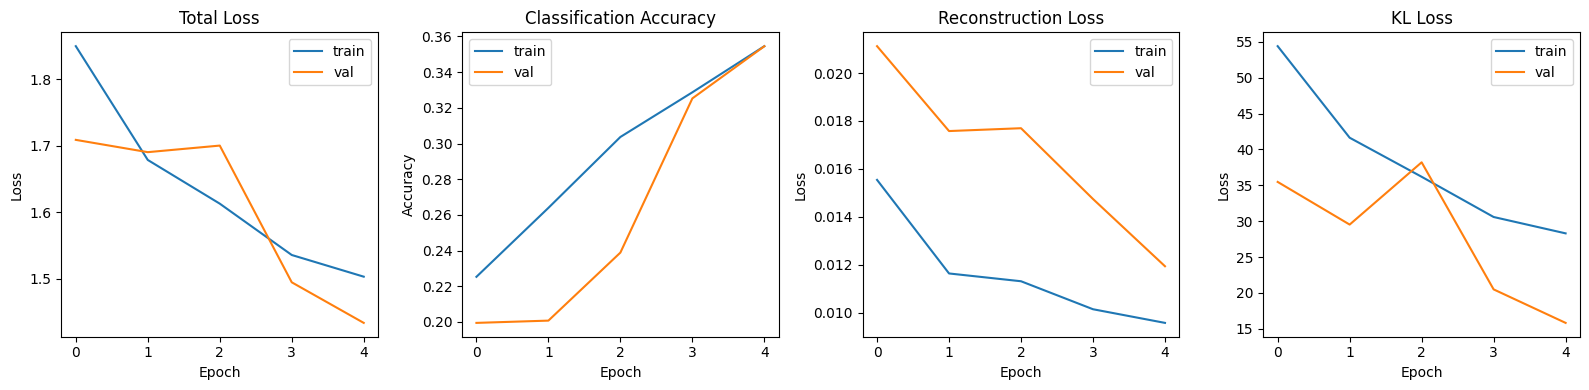

In [27]:
# ============================================================
# PHASE 3.9 - VAE TRAINING CURVES
# ============================================================
def plot_vae_training_history(history):
    hist = history.history

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.title("Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 4, 2)
    plt.plot(hist["classification_accuracy"], label="train")
    plt.plot(hist["val_classification_accuracy"], label="val")
    plt.title("Classification Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 4, 3)
    plt.plot(hist["recon_loss"], label="train")
    plt.plot(hist["val_recon_loss"], label="val")
    plt.title("Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 4, 4)
    plt.plot(hist["kl_loss"], label="train")
    plt.plot(hist["val_kl_loss"], label="val")
    plt.title("KL Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_vae_training_history(history_vae)

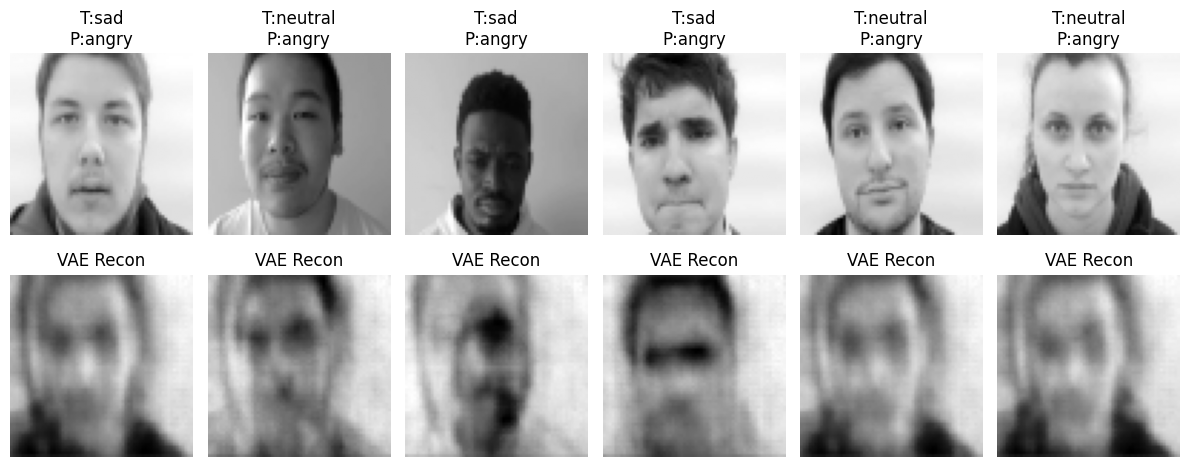

In [28]:
# ============================================================
# PHASE 3.10 - VAE RECONSTRUCTION VISUALIZATION
# ============================================================
def show_vae_reconstructions(model, ds, class_names, n=6):
    for images, labels in ds.take(1):
        images = images[:n]
        labels = labels[:n]
        break

    reconstructions, probs, z_mean, z_log_var, z = model(images, training=False)
    preds = np.argmax(probs.numpy(), axis=1)

    plt.figure(figsize=(2 * n, 5))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(f"T:{class_names[int(labels[i])]}\nP:{class_names[int(preds[i])]}")
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(reconstructions[i].numpy().squeeze(), cmap="gray")
        plt.title("VAE Recon")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_vae_reconstructions(private_vae, test_ds, class_names, n=6)

In [29]:
# ============================================================
# PHASE 3.11 - VAE HEAD EVALUATION
# ============================================================
from sklearn.metrics import accuracy_score, classification_report

y_true_vae = []
y_pred_vae = []

for x_batch, y_batch in test_ds:
    _, probs, _, _, _ = private_vae(x_batch, training=False)
    y_true_vae.append(y_batch.numpy())
    y_pred_vae.append(np.argmax(probs.numpy(), axis=1))

y_true_vae = np.concatenate(y_true_vae, axis=0)
y_pred_vae = np.concatenate(y_pred_vae, axis=0)

vae_head_acc = accuracy_score(y_true_vae, y_pred_vae)

print(f"VAE Head Accuracy: {vae_head_acc:.4f}\n")
print(classification_report(y_true_vae, y_pred_vae, target_names=class_names, digits=4))

VAE Head Accuracy: 0.3452

              precision    recall  f1-score   support

       angry     0.2564    0.8228    0.3910       158
       happy     0.4324    0.1019    0.1649       157
     neutral     0.2973    0.2089    0.2454       158
         sad     0.4000    0.0506    0.0899       158
    surprise     0.7522    0.5414    0.6296       157

    accuracy                         0.3452       788
   macro avg     0.4277    0.3451    0.3042       788
weighted avg     0.4273    0.3452    0.3039       788



In [30]:
# ============================================================
# PHASE 3.12 - EXTRACT VAE LATENT FEATURES
# ============================================================
def extract_vae_latent_features(ds_batched, encoder_model):
    X_latent = []
    y_all = []

    for x_batch, y_batch in ds_batched:
        z_mean, z_log_var, z = encoder_model(x_batch, training=False)
        X_latent.append(z_mean.numpy())
        y_all.append(y_batch.numpy())

    X_latent = np.concatenate(X_latent, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    return X_latent, y_all

X_train_vae, y_train_vae_latent = extract_vae_latent_features(train_ds, vae_encoder)
X_val_vae, y_val_vae_latent     = extract_vae_latent_features(val_ds, vae_encoder)
X_test_vae, y_test_vae_latent   = extract_vae_latent_features(test_ds, vae_encoder)

print("Train latent shape:", X_train_vae.shape)
print("Validation latent shape:", X_val_vae.shape)
print("Test latent shape:", X_test_vae.shape)

Train latent shape: (3675, 64)
Validation latent shape: (787, 64)
Test latent shape: (788, 64)


In [31]:
# ============================================================
# PHASE 3.13 - STANDARDIZE VAE LATENT FEATURES
# ============================================================
from sklearn.preprocessing import StandardScaler

vae_scaler = StandardScaler()
X_train_vae_scaled = vae_scaler.fit_transform(X_train_vae)
X_val_vae_scaled   = vae_scaler.transform(X_val_vae)
X_test_vae_scaled  = vae_scaler.transform(X_test_vae)

print(X_train_vae_scaled.shape, X_test_vae_scaled.shape)

(3675, 64) (788, 64)


In [32]:
# ============================================================
# PHASE 3.14 - VAE LATENT + MLP
# ============================================================
from sklearn.neural_network import MLPClassifier

vae_mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=400,
    random_state=42
)

vae_mlp_classifier.fit(X_train_vae_scaled, y_train_vae_latent)

y_pred_vae_mlp = vae_mlp_classifier.predict(X_test_vae_scaled)
vae_mlp_acc = accuracy_score(y_test_vae_latent, y_pred_vae_mlp)

print(f"VAE Latent + MLP Accuracy: {vae_mlp_acc:.4f}\n")
print(classification_report(y_test_vae_latent, y_pred_vae_mlp, target_names=class_names, digits=4))

VAE Latent + MLP Accuracy: 0.9619

              precision    recall  f1-score   support

       angry     0.9430    0.9430    0.9430       158
       happy     0.9808    0.9745    0.9776       157
     neutral     0.9808    0.9684    0.9745       158
         sad     0.9259    0.9494    0.9375       158
    surprise     0.9808    0.9745    0.9776       157

    accuracy                         0.9619       788
   macro avg     0.9623    0.9620    0.9621       788
weighted avg     0.9622    0.9619    0.9620       788



In [33]:
# ============================================================
# PHASE 3.15-VAE LATENT + LMS CLASSIFIER
# ============================================================
vae_lms_classifier = SGDClassifier(
    loss="squared_error",
    learning_rate="optimal",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

vae_lms_classifier.fit(X_train_vae_scaled, y_train_vae_latent)

y_pred_vae_lms = vae_lms_classifier.predict(X_test_vae_scaled)

vae_lms_acc = accuracy_score(y_test_vae_latent, y_pred_vae_lms)

print(f"VAE Latent + LMS Accuracy: {vae_lms_acc:.4f}\n")

print(classification_report(
    y_test_vae_latent,
    y_pred_vae_lms,
    target_names=class_names,
    digits=4
))

NameError: name 'SGDClassifier' is not defined

In [ ]:
# ============================================================
# PHASE 3.16 - VAE CONFUSION MATRIX
# ============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_conf_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_true_vae, y_pred_vae, class_names, "VAE Head Confusion Matrix")

In [ ]:
# ============================================================
# PHASE 3.17 - VAE RECONSTRUCTION METRICS
# ============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error

def get_vae_reconstruction(model, x_batch):
    reconstruction, probs, z_mean, z_log_var, z = model(x_batch, training=False)
    return reconstruction

def evaluate_vae_reconstruction_metrics(ds, model):
    mse_list = []
    mae_list = []

    for x_batch, _ in ds:
        recon_batch = get_vae_reconstruction(model, x_batch)

        x_true = x_batch.numpy()
        x_rec = recon_batch.numpy()

        for i in range(len(x_true)):
            mse_list.append(mean_squared_error(x_true[i].ravel(), x_rec[i].ravel()))
            mae_list.append(mean_absolute_error(x_true[i].ravel(), x_rec[i].ravel()))

    return {
        "MSE": float(np.mean(mse_list)),
        "MAE": float(np.mean(mae_list)),
    }

vae_recon_metrics = evaluate_vae_reconstruction_metrics(test_ds, private_vae)
print("VAE Reconstruction Metrics:", vae_recon_metrics)

VAE Reconstruction Metrics: {'MSE': 0.020210303802043198, 'MAE': 0.10401420860489209}


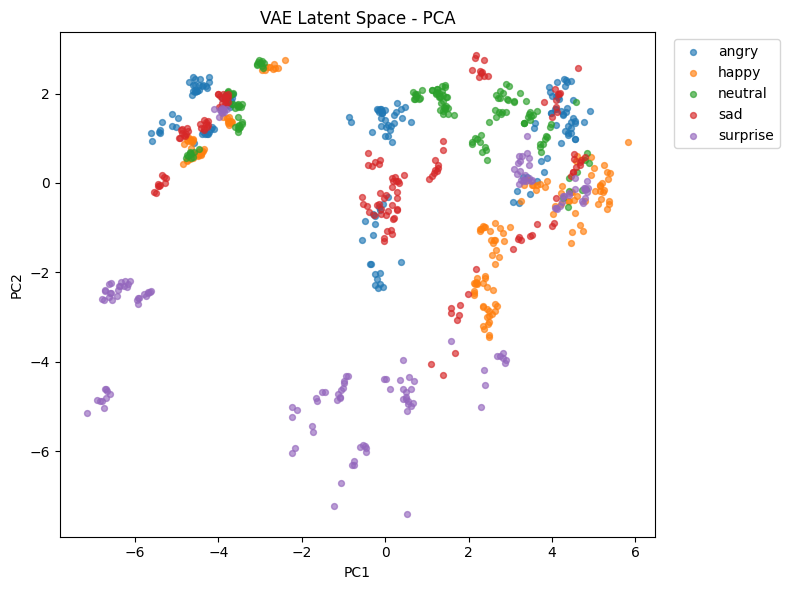

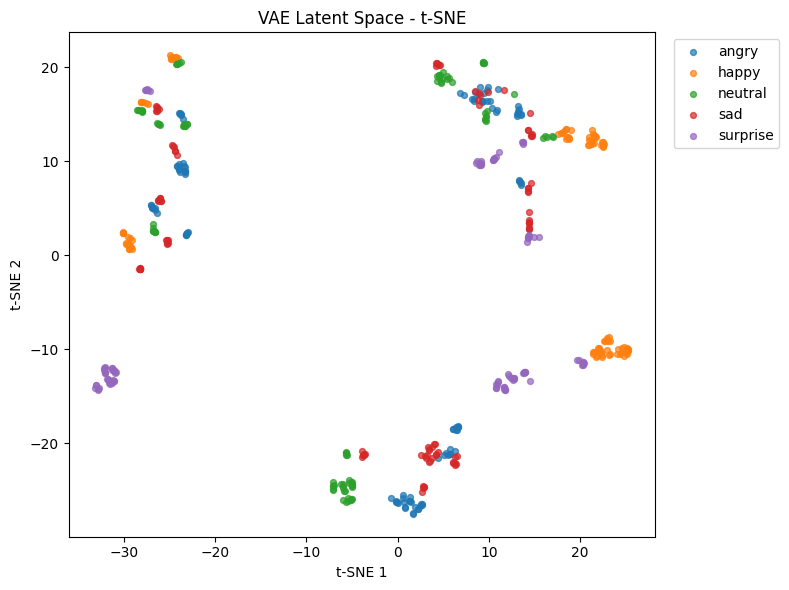

In [ ]:
# ============================================================
# PHASE 3.18 - VAE LATENT SPACE VISUALIZATION
# ============================================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_pca_latent(X, y, class_names, title):
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        mask = (y == i)
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=18, alpha=0.65, label=class_name)

    plt.title(f"{title} - PCA")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_tsne_latent(X, y, class_names, title, sample_size=500):
    rng = np.random.default_rng(42)

    if len(X) > sample_size:
        idx = rng.choice(len(X), sample_size, replace=False)
        X = X[idx]
        y = y[idx]

    X_pca = PCA(n_components=min(20, X.shape[1], len(X) - 1), random_state=42).fit_transform(X)

    X_2d = TSNE(
        n_components=2,
        perplexity=min(30, max(5, len(X) // 10)),
        learning_rate="auto",
        init="pca",
        random_state=42
    ).fit_transform(X_pca)

    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        mask = (y == i)
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=18, alpha=0.70, label=class_name)

    plt.title(f"{title} - t-SNE")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_pca_latent(X_test_vae, y_test_vae_latent, class_names, "VAE Latent Space")
plot_tsne_latent(X_test_vae, y_test_vae_latent, class_names, "VAE Latent Space")

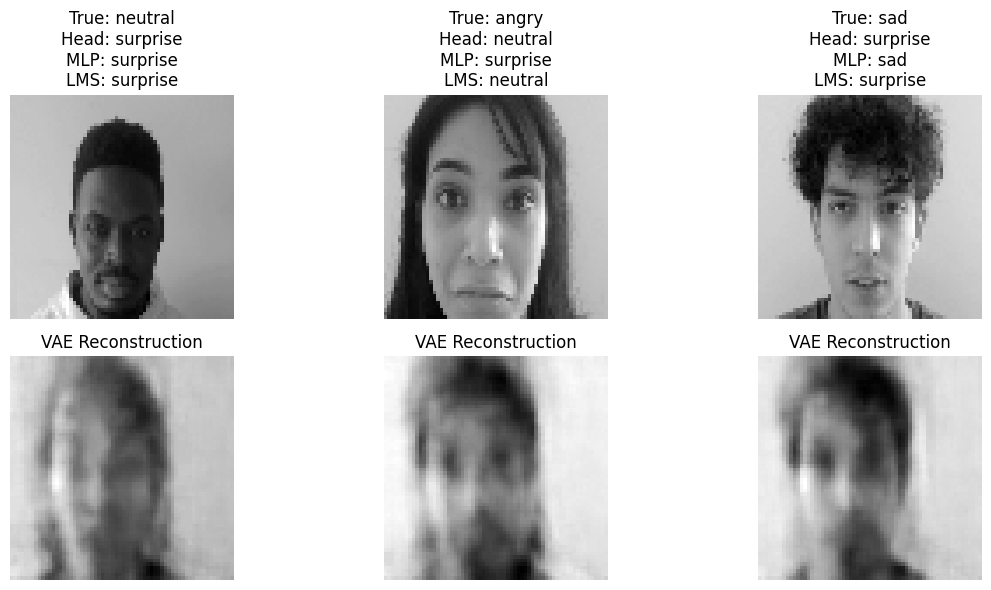

In [ ]:
# ============================================================
# PHASE 3.19 - RANDOM IMAGE PREDICTION (VAE HEAD + MLP + LMS)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

all_test_images = []
all_test_labels = []

for img_batch, lab_batch in test_ds:
    all_test_images.append(img_batch.numpy())
    all_test_labels.append(lab_batch.numpy())

all_test_images = np.concatenate(all_test_images, axis=0)
all_test_labels = np.concatenate(all_test_labels, axis=0)

np.random.seed(42)
indices = np.random.choice(len(all_test_images), size=3, replace=False)

selected_images = all_test_images[indices]
selected_labels = all_test_labels[indices]

# VAE head
reconstructions, vae_head_probs, z_mean, z_log_var, z = private_vae(selected_images, training=False)
vae_head_probs = vae_head_probs.numpy()
vae_head_preds = np.argmax(vae_head_probs, axis=1)

# latent features
latent = vae_encoder(selected_images, training=False)[0].numpy()   # z_mean
latent_scaled = vae_scaler.transform(latent)

# external MLP
mlp_probs = vae_mlp_classifier.predict_proba(latent_scaled)
mlp_preds = np.argmax(mlp_probs, axis=1)

# external LMS
lms_preds = vae_lms_classifier.predict(latent_scaled)

plt.figure(figsize=(12, 6))

for i in range(3):
    plt.subplot(2, 3, i + 1)
    plt.imshow(selected_images[i].squeeze(), cmap="gray")
    plt.title(
        f"True: {class_names[int(selected_labels[i])]}\n"
        f"Head: {class_names[int(vae_head_preds[i])]}\n"
        f"MLP: {class_names[int(mlp_preds[i])]}\n"
        f"LMS: {class_names[int(lms_preds[i])]}"
    )
    plt.axis("off")

    plt.subplot(2, 3, i + 4)
    plt.imshow(reconstructions[i].numpy().squeeze(), cmap="gray")
    plt.title("VAE Reconstruction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PHASE 3.20 - VAE FINAL SUMMARY
# ============================================================
print("=" * 60)
print("PHASE 3 - PRIVATE DATASET VAE SUMMARY")
print("=" * 60)
print(f"VAE Head Accuracy       : {vae_head_acc:.4f}")
print(f"VAE Latent + MLP        : {vae_mlp_acc:.4f}")
print(f"VAE Latent + LMS     : {vae_lms_acc:.4f}")
print(f"VAE Reconstruction MSE  : {vae_recon_metrics['MSE']:.6f}")
print(f"VAE Reconstruction MAE  : {vae_recon_metrics['MAE']:.6f}")

PHASE 3 - PRIVATE DATASET VAE SUMMARY
VAE Head Accuracy       : 0.3547
VAE Latent + MLP        : 0.3853
VAE Latent + LMS     : 0.3200
VAE Reconstruction MSE  : 0.020210
VAE Reconstruction MAE  : 0.104014


In [ ]:
# ============================================================
# FINAL AE vs VAE COMPARISON
# ============================================================

print("\n")
print("=" * 65)
print("FINAL AE vs VAE COMPARISON")
print("=" * 65)

print(f"{'Model':<25}{'Head':<12}{'Latent+MLP':<15}{'Latent+LMS':<15}")
print("-" * 65)

print(f"{'Autoencoder (AE)':<25}{ae_head_acc:<12.4f}{ae_mlp_acc:<15.4f}{ae_lms_acc:<15.4f}")
print(f"{'Variational AE (VAE)':<25}{vae_head_acc:<12.4f}{vae_mlp_acc:<15.4f}{vae_lms_acc:<15.4f}")

print("-" * 65)
print("\n")


# ============================================================
# RECONSTRUCTION QUALITY COMPARISON
# ============================================================

print("=" * 65)
print("RECONSTRUCTION QUALITY COMPARISON")
print("=" * 65)

print(f"{'Model':<25}{'MSE':<15}{'MAE':<15}")
print("-" * 65)

print(f"{'Autoencoder (AE)':<25}{ae_recon_metrics['MSE']:<15.6f}{ae_recon_metrics['MAE']:<15.6f}")
print(f"{'Variational AE (VAE)':<25}{vae_recon_metrics['MSE']:<15.6f}{vae_recon_metrics['MAE']:<15.6f}")

print("-" * 65)



FINAL AE vs VAE COMPARISON
Model                    Head        Latent+MLP     Latent+LMS     
-----------------------------------------------------------------
Autoencoder (AE)         0.2627      0.3787         0.2067         
Variational AE (VAE)     0.3547      0.3853         0.3200         
-----------------------------------------------------------------


RECONSTRUCTION QUALITY COMPARISON
Model                    MSE            MAE            
-----------------------------------------------------------------
Autoencoder (AE)         0.023520       0.104752       
Variational AE (VAE)     0.020210       0.104014       
-----------------------------------------------------------------


In [ ]:
# ============================================================
# PHASE 2.1 - SHARED CONVOLUTION BLOCK
# ============================================================
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def ae_conv_block(x, filters, l2_reg=1e-4, dropout_rate=0.15):
    x = layers.Conv2D(
        filters=filters,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

In [ ]:
# ============================================================
# PHASE 2.2 - AE ENCODER
# ============================================================
def build_private_ae_encoder(cfg):
    inputs = layers.Input(shape=(*cfg.image_size, cfg.channels), name="ae_encoder_input")

    x = data_augmentation(inputs)

    x = ae_conv_block(x, 32, l2_reg=1e-4, dropout_rate=0.10)
    x = ae_conv_block(x, 64, l2_reg=1e-4, dropout_rate=0.15)
    x = ae_conv_block(x, 128, l2_reg=1e-4, dropout_rate=0.20)

    shape_before_flatten = tf.keras.backend.int_shape(x)[1:]

    x = layers.Flatten()(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.25)(x)

    latent = layers.Dense(cfg.latent_dim, name="ae_latent")(x)

    encoder = models.Model(inputs, latent, name="Private_AE_Encoder")
    return encoder, shape_before_flatten

ae_encoder, ae_shape_before_flatten = build_private_ae_encoder(CFG)
ae_encoder.summary()

print("Shape before flatten:", ae_shape_before_flatten)

Model: "Private_AE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_encoder_input (InputLayer)   │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_188         │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_188 (LeakyReLU)     │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_189         │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_189 (LeakyReLU)     │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_190         │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_190 (LeakyReLU)     │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_191         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_191 (LeakyReLU)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_98 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_latent (Dense)               │ (None, 64)             │         8,25

 Total params: 1,151,040 (4.39 MB)

 Trainable params: 1,150,336 (4.39 MB)

 Non-trainable params: 704 (2.75 KB)

Shape before flatten: (8, 8, 128)


In [ ]:
# ============================================================
# PHASE 2.3 - AE DECODER
# ============================================================
def build_private_ae_decoder(cfg, shape_before_flatten):
    latent_inputs = layers.Input(shape=(cfg.latent_dim,), name="ae_decoder_input")

    h, w, c = shape_before_flatten

    x = layers.Dense(h * w * c)(latent_inputs)
    x = layers.Reshape((h, w, c))(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)

    x = layers.Conv2D(cfg.channels, 3, padding="same", activation="sigmoid")(x)

    # ensure exact final size
    x = layers.Resizing(cfg.image_size[0], cfg.image_size[1])(x)

    decoder = models.Model(latent_inputs, x, name="Private_AE_Decoder")
    return decoder

ae_decoder = build_private_ae_decoder(CFG, ae_shape_before_flatten)
ae_decoder.summary()

Model: "Private_AE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_decoder_input (InputLayer)   │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 8192)           │       532,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_14 (Reshape)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_50             │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_51             │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_52             │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_108 (Conv2D)             │ (None, 64, 64, 1)      │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 64, 64, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 772,609 (2.95 MB)

 Trainable params: 772,609 (2.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# PHASE 2.4 - AE CLASSIFIER HEAD
# ============================================================
def build_private_ae_head(cfg, num_classes):
    inputs = layers.Input(shape=(cfg.latent_dim,), name="ae_head_input")

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    head = models.Model(inputs, outputs, name="Private_AE_Head")
    return head

ae_head = build_private_ae_head(CFG, num_classes)
ae_head.summary()

Model: "Private_AE_Head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_head_input (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_192         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_192 (LeakyReLU)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,741 (18.52 KB)

 Trainable params: 4,613 (18.02 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# ============================================================
# PHASE 2.5 - SUPERVISED AE MODEL
# ============================================================
class SupervisedAE(tf.keras.Model):
    def __init__(
        self,
        encoder,
        decoder,
        classifier,
        reconstruction_loss_weight=0.6,
        classification_loss_weight=1.0,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.classifier = classifier

        self.reconstruction_loss_weight = reconstruction_loss_weight
        self.classification_loss_weight = classification_loss_weight

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.cls_loss_tracker = tf.keras.metrics.Mean(name="cls_loss")
        self.acc_tracker = tf.keras.metrics.SparseCategoricalAccuracy(name="classification_accuracy")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.cls_loss_tracker,
            self.acc_tracker,
        ]

    def call(self, inputs, training=False):
        latent = self.encoder(inputs, training=training)
        reconstruction = self.decoder(latent, training=training)
        class_probs = self.classifier(latent, training=training)
        return reconstruction, class_probs

    def compute_reconstruction_loss(self, x_true, x_recon):
        per_sample = tf.reduce_mean(tf.square(x_true - x_recon), axis=[1, 2, 3])
        return tf.reduce_mean(per_sample)

    def compute_classification_loss(self, y_true, probs):
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, probs)
        return tf.reduce_mean(loss)

    def train_step(self, data):
        x, y = data

        with tf.GradientTape() as tape:
            reconstruction, probs = self(x, training=True)

            recon_loss = self.compute_reconstruction_loss(x, reconstruction)
            cls_loss = self.compute_classification_loss(y, probs)

            total_loss = (
                self.reconstruction_loss_weight * recon_loss +
                self.classification_loss_weight * cls_loss
            )

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.cls_loss_tracker.update_state(cls_loss)
        self.acc_tracker.update_state(y, probs)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data

        reconstruction, probs = self(x, training=False)

        recon_loss = self.compute_reconstruction_loss(x, reconstruction)
        cls_loss = self.compute_classification_loss(y, probs)

        total_loss = (
            self.reconstruction_loss_weight * recon_loss +
            self.classification_loss_weight * cls_loss
        )

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.cls_loss_tracker.update_state(cls_loss)
        self.acc_tracker.update_state(y, probs)

        return {m.name: m.result() for m in self.metrics}

In [ ]:
# ============================================================
# PHASE 2.6 - INSTANTIATE AND COMPILE AE
# ============================================================
private_ae = SupervisedAE(
    encoder=ae_encoder,
    decoder=ae_decoder,
    classifier=ae_head,
    reconstruction_loss_weight=0.8,# tune here 0.6,0.3,1.0
    classification_loss_weight=1.2,
    name="PrivateSupervisedAE"
)

optimizer = tf.keras.optimizers.Adam(learning_rate=CFG.learning_rate)

private_ae.compile(
    optimizer=optimizer,
    run_eagerly=True,
    jit_compile=False
)

In [ ]:
import tensorflow as tf
tf.config.optimizer.set_jit(False)
print("XLA JIT disabled.")

XLA JIT disabled.


In [ ]:
# ============================================================
# PHASE 2.7 - TRAIN AE
# ============================================================
ae_checkpoint_path = "best_private_ae.weights.h5"

callbacks_ae = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ae_checkpoint_path,
        monitor="val_classification_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_classification_accuracy",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_classification_accuracy",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history_ae = private_ae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.epochs,
    callbacks=callbacks_ae,
    verbose=1
)

private_ae.load_weights(ae_checkpoint_path)
print("Best AE weights loaded.")

Epoch 1/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - classification_accuracy: 0.2099 - cls_loss: 1.9373 - loss: 2.3412 - recon_loss: 0.0205
Epoch 1: val_classification_accuracy improved from None to 0.19187, saving model to best_private_ae.weights.h5

Epoch 1: finished saving model to best_private_ae.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 355ms/step - classification_accuracy: 0.2163 - cls_loss: 1.8174 - loss: 2.1927 - recon_loss: 0.0149 - val_classification_accuracy: 0.1919 - val_cls_loss: 1.7117 - val_loss: 2.0729 - val_recon_loss: 0.0235 - learning_rate: 0.0010
Epoch 2/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - classification_accuracy: 0.2396 - cls_loss: 1.6846 - loss: 2.0286 - recon_loss: 0.0088
Epoch 2: val_classification_accuracy improved from 0.19187 to 0.21982, saving model to best_private_ae.weights.h5

Epoch 2: finished saving model to best_private_ae.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 357ms/step - classification_accuracy: 0.2465 - cls_loss: 1.6681 - loss

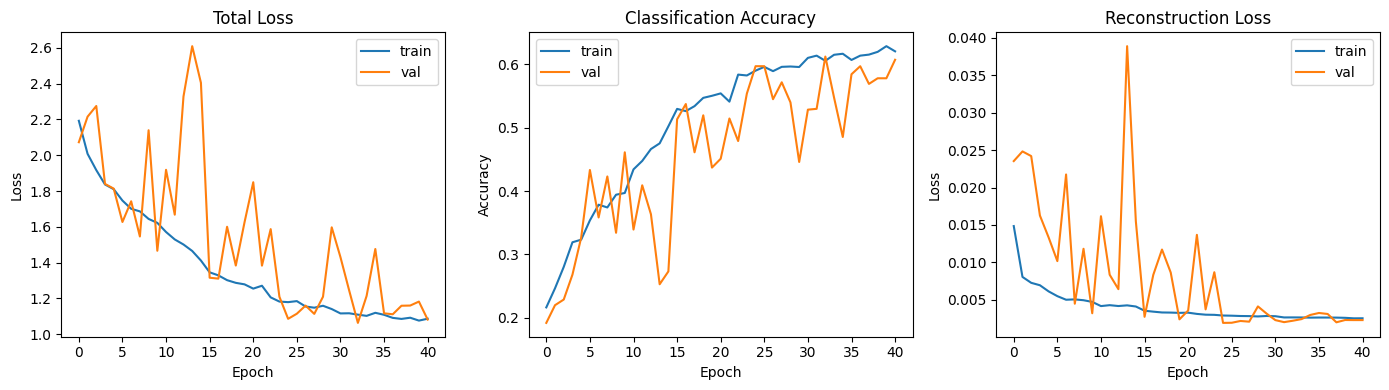

In [ ]:
# ============================================================
# PHASE 2.8 - TRAINING CURVES
# ============================================================
def plot_ae_training_history(history):
    hist = history.history

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.title("Total Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(hist["classification_accuracy"], label="train")
    plt.plot(hist["val_classification_accuracy"], label="val")
    plt.title("Classification Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(hist["recon_loss"], label="train")
    plt.plot(hist["val_recon_loss"], label="val")
    plt.title("Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_ae_training_history(history_ae)

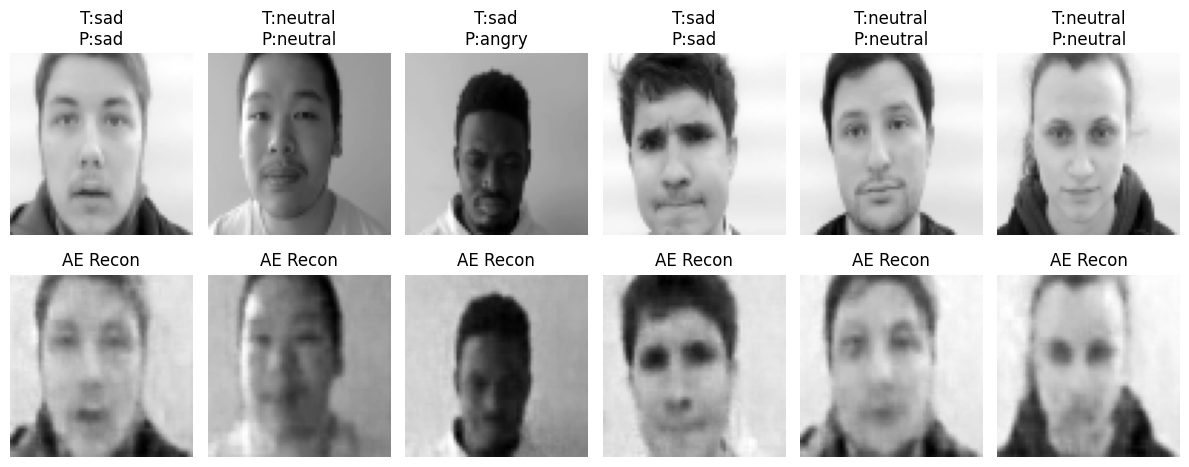

In [ ]:
# ============================================================
# PHASE 2.9 - AE RECONSTRUCTION VISUALIZATION
# ============================================================
def show_ae_reconstructions(model, ds, class_names, n=6):
    for images, labels in ds.take(1):
        images = images[:n]
        labels = labels[:n]
        break

    reconstructions, probs = model(images, training=False)
    preds = np.argmax(probs.numpy(), axis=1)

    plt.figure(figsize=(2 * n, 5))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(f"T:{class_names[int(labels[i])]}\nP:{class_names[int(preds[i])]}")
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(reconstructions[i].numpy().squeeze(), cmap="gray")
        plt.title("AE Recon")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ae_reconstructions(private_ae, test_ds, class_names, n=6)

In [ ]:
# ============================================================
# PHASE 2.10 - AE HEAD EVALUATION
# ============================================================
from sklearn.metrics import accuracy_score, classification_report

y_true_ae = []
y_pred_ae = []

for x_batch, y_batch in test_ds:
    _, probs = private_ae(x_batch, training=False)
    y_true_ae.append(y_batch.numpy())
    y_pred_ae.append(np.argmax(probs.numpy(), axis=1))

y_true_ae = np.concatenate(y_true_ae, axis=0)
y_pred_ae = np.concatenate(y_pred_ae, axis=0)

ae_head_acc = accuracy_score(y_true_ae, y_pred_ae)

print(f"AE Head Accuracy: {ae_head_acc:.4f}\n")
print(classification_report(y_true_ae, y_pred_ae, target_names=class_names, digits=4))

AE Head Accuracy: 0.6574

              precision    recall  f1-score   support

       angry     0.5000    0.8354    0.6256       158
       happy     0.7528    0.8535    0.8000       157
     neutral     0.7606    0.3418    0.4716       158
         sad     0.4845    0.2975    0.3686       158
    surprise     0.8483    0.9618    0.9015       157

    accuracy                         0.6574       788
   macro avg     0.6692    0.6580    0.6335       788
weighted avg     0.6689    0.6574    0.6329       788



# its new testing from resnet 18 and attention ways

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models

class EmotionVAE(nn.Module):
    def __init__(self, latent_dim=128, num_classes=5, input_channels=1):
        super(EmotionVAE, self).__init__()
        self.latent_dim = latent_dim

        # ==========================================
        # 1. ENCODER (ResNet-18 based)
        # ==========================================
        resnet = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
        resnet.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.encoder_features = nn.Sequential(*list(resnet.children())[:-2])

        # Project to flat latent vector
        self.fc_mu = nn.Linear(512 * 2 * 2, latent_dim)
        self.fc_logvar = nn.Linear(512 * 2 * 2, latent_dim)

        # ==========================================
        # 2. MLP CLASSIFIER
        # ==========================================
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

        # ==========================================
        # 3. DECODER
        # ==========================================
        self.decoder_input = nn.Linear(latent_dim, 512 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, input_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_features(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(x.size(0), 512, 4, 4)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        class_logits = self.classifier(z)
        return reconstruction, mu, logvar, class_logits, z

In [31]:
def vae_emotion_loss(reconstruction, original, mu, logvar, logits, labels,
                     kl_weight=0.001, cls_weight=1.0, recon_weight=0.6):

    # 1. Reconstruction Loss (Mean Squared Error)
    # Using sum reduction so it scales well with the image size
    recon_loss = F.mse_loss(reconstruction, original, reduction='sum') / original.size(0)

    # 2. KL Divergence Loss
    # Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / original.size(0)

    # 3. Classification Loss (Cross Entropy for 5 classes)
    cls_loss = F.cross_entropy(logits, labels, reduction='mean')

    # Weighted total loss
    total_loss = (recon_weight * recon_loss) + (kl_weight * kl_loss) + (cls_weight * cls_loss)

    return total_loss, recon_loss, kl_loss, cls_loss

In [32]:
# # Initialization
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = EmotionVAE(latent_dim=128, num_classes=5).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# # Training Step
# model.train()
# for epoch in range(num_epochs):
#     for batch_idx, (images, labels) in enumerate(dataloader):
#         images, labels = images.to(device), labels.to(device)

#         # Forward pass
#         reconstruction, mu, logvar, logits, z = model(images)

#         # Calculate loss
#         total_loss, recon_loss, kl_loss, cls_loss = vae_emotion_loss(
#             reconstruction, images, mu, logvar, logits, labels,
#             kl_weight=0.005, cls_weight=5.0
#         )

#         # Backward pass
#         optimizer.zero_grad()
#         total_loss.backward()
#         optimizer.step()

#         if batch_idx % 50 == 0:
#             print(f"Epoch [{epoch}] | Total Loss: {total_loss.item():.4f} | "
#                   f"Recon: {recon_loss.item():.4f} | KL: {kl_loss.item():.4f} | "
#                   f"Cls: {cls_loss.item():.4f}")

In [33]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

class EmotionPyTorchDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        label = self.df.iloc[idx]['label_id']

        # Load as Grayscale
        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# ============================================================
# UPDATED TRANSFORMS WITH DATA AUGMENTATION
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(), # Scales to [0, 1]
])

# Validation transform should NOT have random augmentation
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Create DataLoaders
train_dataset_pt = EmotionPyTorchDataset(df_train, transform=train_transform)
val_dataset_pt = EmotionPyTorchDataset(df_val, transform=val_transform)

train_loader = DataLoader(train_dataset_pt, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset_pt, batch_size=32, shuffle=False)

print(f"PyTorch DataLoaders with Augmentation ready.")



PyTorch DataLoaders with Augmentation ready.


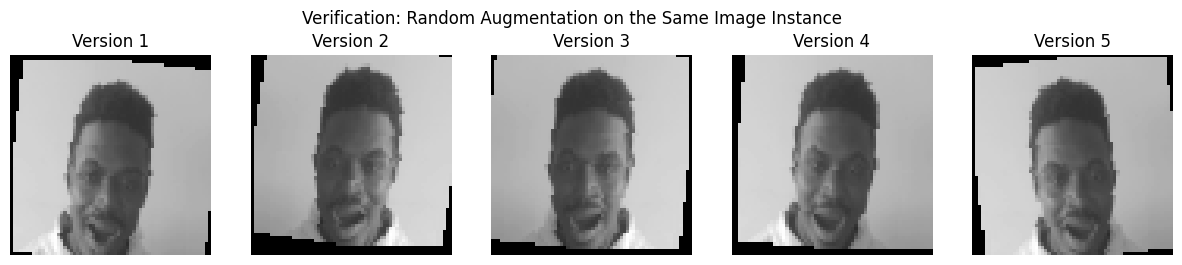

In [34]:
import matplotlib.pyplot as plt

# Let's look at 5 different versions of the SAME image from the training loader
def check_augmentation_variance(dataset, index=0):
    plt.figure(figsize=(15, 3))
    for i in range(5):
        # Each time we call __getitem__, the random transforms are applied
        img, label = dataset[index]
        plt.subplot(1, 5, i + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"Version {i+1}")
        plt.axis('off')
    plt.suptitle("Verification: Random Augmentation on the Same Image Instance")
    plt.show()

check_augmentation_variance(train_dataset_pt, index=10)

In [35]:
len(df)

5250

In [36]:
len(train_dataset_pt)

3675

In [ ]:
# Initialization
num_epochs = 25
warmup_epochs = 5
import torchvision.models as tv_models
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Using standard flat 128-dim latent space
model = EmotionVAE(latent_dim=128, num_classes=5, input_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

history = {
    'train_loss': [], 'train_recon': [], 'train_kl': [], 'train_cls': [], 'train_acc': [],
    'val_loss': [], 'val_recon': [], 'val_kl': [], 'val_cls': [], 'val_acc': []
}

print(f"Starting training on {device} with 128-dim latent space...")

for epoch in range(num_epochs):
    start_time = time.time()
    if epoch < warmup_epochs:
        for param in model.encoder_features.parameters(): param.requires_grad = False
        status = "[Warmup]"
    else:
        for param in model.encoder_features.parameters(): param.requires_grad = True
        status = "[Fine-tuning]"

    model.train()
    t_loss, t_recon, t_kl, t_cls, t_acc = 0, 0, 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        reconstruction, mu, logvar, logits, z = model(images)
        loss, recon, kl, cls_l = vae_emotion_loss(
            reconstruction, images, mu, logvar, logits, labels,
            kl_weight=0.001, cls_weight=1.0, recon_weight=2.0
        )
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        t_loss += loss.item(); t_recon += recon.item(); t_kl += kl.item(); t_cls += cls_l.item()
        t_acc += (torch.argmax(logits, dim=1) == labels).sum().item()

    model.eval()
    v_loss, v_recon, v_kl, v_cls, v_acc = 0, 0, 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            reconstruction, mu, logvar, logits, z = model(images)
            loss, recon, kl, cls_l = vae_emotion_loss(
                reconstruction, images, mu, logvar, logits, labels,
                kl_weight=0.001, cls_weight=1.0, recon_weight=2.0
            )
            v_loss += loss.item(); v_recon += recon.item(); v_kl += kl.item(); v_cls += cls_l.item()
            v_acc += (torch.argmax(logits, dim=1) == labels).sum().item()

    n_train_batches, n_val_batches = len(train_loader), len(val_loader)
    cur_train_acc = t_acc / len(df_train)
    cur_val_acc = v_acc / len(df_val)

    # Store all metrics in history
    history['train_loss'].append(t_loss/n_train_batches)
    history['train_recon'].append(t_recon/n_train_batches)
    history['train_kl'].append(t_kl/n_train_batches)
    history['train_cls'].append(t_cls/n_train_batches)
    history['train_acc'].append(cur_train_acc)

    history['val_loss'].append(v_loss/n_val_batches)
    history['val_recon'].append(v_recon/n_val_batches)
    history['val_kl'].append(v_kl/n_val_batches)
    history['val_cls'].append(v_cls/n_val_batches)
    history['val_acc'].append(cur_val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} {status} - Train Acc: {cur_train_acc:.4f} - Val Acc: {cur_val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 372MB/s]


Starting training on cpu with 128-dim latent space...
Epoch 1/25 [Warmup] - Train Acc: 0.2005 - Val Acc: 0.2122
Epoch 2/25 [Warmup] - Train Acc: 0.2011 - Val Acc: 0.2186
Epoch 3/25 [Warmup] - Train Acc: 0.2071 - Val Acc: 0.2097
Epoch 4/25 [Warmup] - Train Acc: 0.1989 - Val Acc: 0.2186
Epoch 5/25 [Warmup] - Train Acc: 0.2005 - Val Acc: 0.2262
Epoch 6/25 [Fine-tuning] - Train Acc: 0.2103 - Val Acc: 0.1970
Epoch 7/25 [Fine-tuning] - Train Acc: 0.2046 - Val Acc: 0.1970
Epoch 8/25 [Fine-tuning] - Train Acc: 0.2093 - Val Acc: 0.2122


In [ ]:
import matplotlib.pyplot as plt

def plot_vae_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(25, 5))

    # 1. Total Loss
    plt.subplot(1, 5, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train')
    plt.plot(epochs, history['val_loss'], 'r--', label='Val')
    plt.title('Total Loss')
    plt.legend()

    # 2. Reconstruction Loss
    plt.subplot(1, 5, 2)
    plt.plot(epochs, history['train_recon'], 'g-', label='Train')
    plt.plot(epochs, history['val_recon'], 'y--', label='Val')
    plt.title('Recon Loss')
    plt.legend()

    # 3. KL Divergence Loss
    plt.subplot(1, 5, 3)
    plt.plot(epochs, history['train_kl'], 'c-', label='Train')
    plt.plot(epochs, history['val_kl'], 'm--', label='Val')
    plt.title('KL Loss')
    plt.legend()

    # 4. Classification Loss
    plt.subplot(1, 5, 4)
    plt.plot(epochs, history['train_cls'], 'm-', label='Train')
    plt.plot(epochs, history['val_cls'], 'k--', label='Val')
    plt.title('Classification Loss')
    plt.legend()

    # 5. Accuracy (Train vs Val)
    plt.subplot(1, 5, 5)
    plt.plot(epochs, history['train_acc'], 'b-o', label='Train')
    plt.plot(epochs, history['val_acc'], 'r-o', label='Val')
    plt.title('Classification Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_vae_history(history)

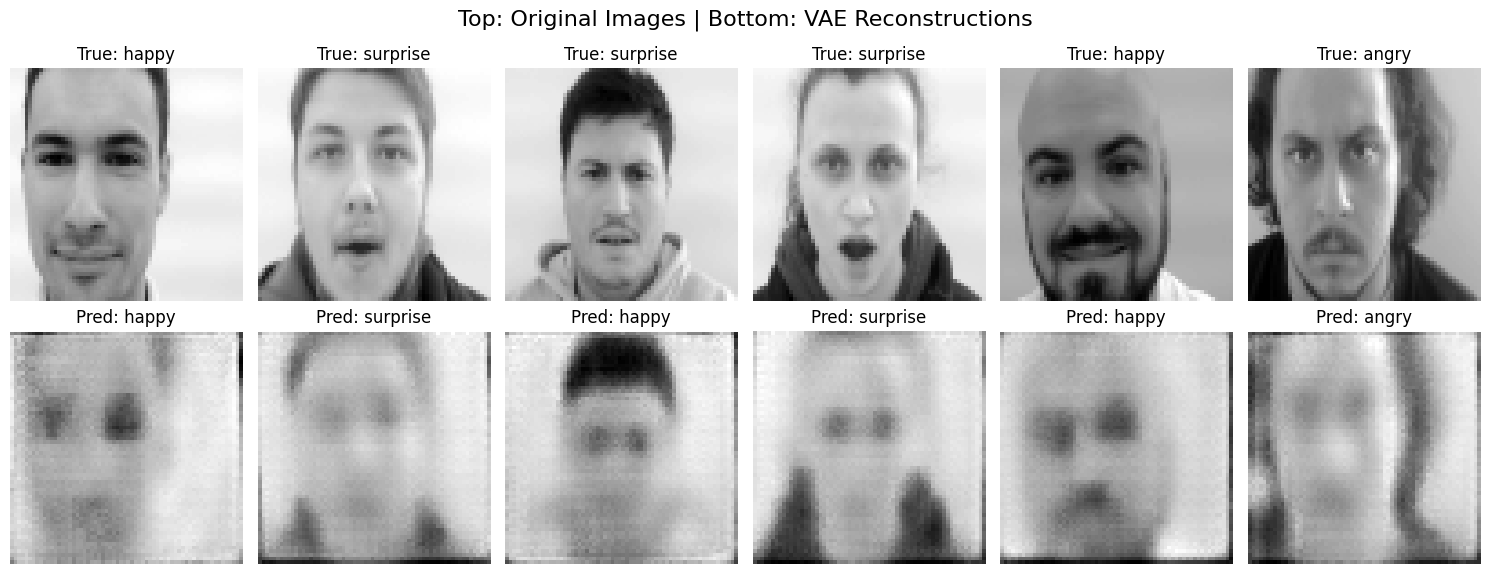

In [73]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_vae_reconstruction(model, dataloader, device, class_names, n=6):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        reconstruction, mu, logvar, logits, z = model(images)
        preds = torch.argmax(logits, dim=1)

    # Move to CPU for plotting
    images = images.cpu().numpy()
    reconstruction = reconstruction.cpu().numpy()
    labels = labels.cpu().numpy()
    preds = preds.cpu().numpy()

    plt.figure(figsize=(15, 6))
    for i in range(n):
        # Plot Original
        plt.subplot(2, n, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f"True: {class_names[labels[i]]}")
        plt.axis('off')

        # Plot Reconstruction
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstruction[i].squeeze(), cmap='gray')
        plt.title(f"Pred: {class_names[preds[i]]}")
        plt.axis('off')

    plt.suptitle("Top: Original Images | Bottom: VAE Reconstructions", fontsize=16)
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_vae_reconstruction(model, val_loader, device, class_names, n=6)